# 03rl · FunnyBirds visibility-aware labels
## Did contradictory concept supervision cause the backwash found in notebook 02?

This notebook is the causal follow-up to **02 · FunnyBirds CBM**. It does not begin
with an RLv2 result. It begins with the observations that motivated the intervention,
states predictions before showing outcomes, and then repeats every necessary notebook-02
control as a direct **standard versus RLv2** comparison.

**RLv2 is relabeling, not reinforcement learning.**

For a concept group \(j\),

\[
c_j^{RLv2}=c_j\times \mathbf{1}[\text{part }j\text{ is visibly present}].
\]

Images, architecture, optimizer, loss family, seed, checkpoint epoch, and evaluation
interventions are held fixed. Only low-visibility training targets change.

**Current evidential scope.** The fixed-render result below is seed 1 at epoch 100.
Rows are paired by `render_id` and `image_cf_sha256`. Species-pair bootstrap intervals
describe uncertainty across tested interventions, not retraining variability. Seeds 2–3
and the independent RLv2 deletion experiment remain required for a stable general claim.


## 0 · The complete pre-result prediction

Notebook 02 established this sequence:

1. Ordinary images look grounded: the present source concept is ON and absent alternatives
   are OFF.
2. Deletion lowers every part concept, but tail retains more support than the others.
3. Valid part replacement reveals graded backwash: tail is worst, beak and eye also fail
   often, while foot and wing usually follow their pixels.
4. Donor scores usually rise after replacement, including for tail. The model is not simply
   blind; the removed source concept often remains too strong.
5. Low test-time visibility explains part, but not all, of the problem.
6. Training-label audit reveals the missing intervention: non-placeholder parts can have
   a positive target despite negligible visible area.
7. Variant pair and source species remain alternative explanations.

RLv2 changes the gradient on those contradictory training examples. Before looking at any
RLv2 result, define four scores for each replacement:

| score | image | expected RLv2 effect |
|---|---|---|
| `S_orig` | source concept on original image | stable if visible; lower if hidden |
| `D_orig` | absent donor concept on original image | stable or lower |
| `S_swap` | removed source concept after swap | **lower** |
| `D_swap` | inserted donor concept after swap | stable or higher |

Therefore the primary prediction is

\[
margin_{swap}=D_{swap}-S_{swap}\ \uparrow,\qquad
P(margin_{swap}>0)\ \uparrow.
\]

The secondary sensitivity diagnostic is

\[
response_\Delta=(D_{swap}-S_{swap})-(D_{orig}-S_{orig}).
\]

It should usually rise if insertion/removal sensitivity strengthens, but it is not an
unaffected-control estimate: RLv2 intentionally changes low-visibility original images too.

**Part-level prediction, before results:** tail largest; beak and eye moderate; foot small;
wing approximately unchanged. RLv2 should reduce, not necessarily eliminate, tail failure
because it does not remove the nine-variant/species-correlation structure.


In [1]:
import os, re, glob, json, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

CWD = Path.cwd()
REPO = CWD if (CWD/"analysis").is_dir() else CWD.parent
CURATED_DATA = Path(os.environ["CURATED_DATA"])
ORDER = ["tail", "beak", "eye", "foot", "wing"]
COLORS = {
    "standard": "#0072B2", "RLv2": "#009E73",
    "tail": "#6A0DAD", "beak": "#8C6D31", "eye": "#D4A017",
    "foot": "#2CA02C", "wing": "#1F77B4",
}
MODEL_FILES = {
    "CBM": ("funnybirds-cbm-s1.csv", "funnybirds-cbm-rlv2matched-s1.csv"),
    "MCBM γ=0": ("funnybirds-mcbm-g0-s1.csv", "funnybirds-mcbm-rlv2matched-g0-s1.csv"),
    "MCBM γ=0.1": ("funnybirds-mcbm-g0p1-s1.csv", "funnybirds-mcbm-rlv2matched-g0p1-s1.csv"),
}

candidates = [
    Path(os.environ["FIXED_SWAP_DIR"]) if os.environ.get("FIXED_SWAP_DIR") else None,
    CURATED_DATA/"swap_fixed_v3_matched",
    CURATED_DATA/"swap_fixed_v2_attempt2",
    CURATED_DATA/"swap_fixed_v2",
]
required = {name for pair in MODEL_FILES.values() for name in pair}
SWAP_DIR = next(
    (p for p in candidates if p is not None and p.exists()
     and required.issubset({x.name for x in p.glob("*.csv")})),
    None,
)
if SWAP_DIR is None:
    raise FileNotFoundError(
        "No validated fixed-render directory contains all six seed-1 CSVs. "
        "Set FIXED_SWAP_DIR explicitly; legacy swap/ and swap_fixed_v1 are not accepted."
    )

def load_pair(model):
    standard_name, rl_name = MODEL_FILES[model]
    standard = pd.read_csv(SWAP_DIR/standard_name)
    rl = pd.read_csv(SWAP_DIR/rl_name)
    key = ["render_id"]
    q = standard.merge(
        rl, on=key, validate="one_to_one", suffixes=("_standard", "_rl")
    )
    for c in ["image_cf_sha256", "image_orig_sha256", "part", "direction",
              "sid_src", "sid_donor", "var_src", "var_donor", "li"]:
        if not (q[f"{c}_standard"] == q[f"{c}_rl"]).all():
            raise ValueError(f"{model}: paired column differs: {c}")
        q[c] = q[f"{c}_standard"]
    q["model"] = model
    q["pair_id"] = q.apply(
        lambda r: f"{r['part']}:{min(r.sid_src,r.sid_donor)}-{max(r.sid_src,r.sid_donor)}",
        axis=1,
    )
    return standard, rl, q

RAW = {}
PAIRED = {}
for model in MODEL_FILES:
    standard, rl, paired = load_pair(model)
    RAW[(model, "standard")] = standard
    RAW[(model, "RLv2")] = rl
    PAIRED[model] = paired

def cluster_ci(frame, value, reps=5000, seed=20260730):
    g = frame.groupby("pair_id")[value].agg(["sum", "size"]).reset_index(drop=True)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(g), size=(reps, len(g)))
    draws = g["sum"].to_numpy()[idx].sum(1) / g["size"].to_numpy()[idx].sum(1)
    return np.quantile(draws, [0.025, 0.975])

def concept_columns(frame, part):
    return sorted(
        [c for c in frame if c.startswith(f"z_cf_{part}_")],
        key=lambda c: int(c.rsplit("_", 1)[1]),
    )

print(f"Validated fixed-render directory: {SWAP_DIR}")


Validated fixed-render directory: /scratch/network/cr7998/cv_emergence_project/curated_data/swap_fixed_v3_matched


## 1 · Fail-closed evaluation audit

**Question.** Are standard and RLv2 models being compared on exactly the same images?

**Prediction.** Every pair must have the same `render_id`, original hash, counterfactual
hash, source/donor species, variants, direction, and local image index. Any mismatch
invalidates the comparison before model behavior is interpreted.


In [2]:
audit = []
reference = None
for model, q in PAIRED.items():
    ids = set(q.render_id)
    if reference is None:
        reference = ids
    audit.append({
        "model": model,
        "rows": len(q),
        "unique_counterfactuals": q.image_cf_sha256_standard.nunique(),
        "unique_originals": q.image_orig_sha256_standard.nunique(),
        "same_render_set_as_CBM": ids == reference,
        "all_cf_hashes_match_within_pair":
            (q.image_cf_sha256_standard == q.image_cf_sha256_rl).all(),
        "parts": ",".join(sorted(q.part.unique())),
        "directions": ",".join(sorted(q.direction.unique())),
    })
AUDIT = pd.DataFrame(audit)
display(AUDIT)
assert AUDIT.same_render_set_as_CBM.all()
assert AUDIT.all_cf_hashes_match_within_pair.all()
assert (AUDIT.rows == 5000).all()
print("FIXED-IMAGE AUDIT PASSED. Interpretation may proceed.")


,model,rows,unique_counterfactuals,unique_originals,same_render_set_as_CBM,all_cf_hashes_match_within_pair,parts,directions
0,CBM,5000,3040,250,True,True,"beak,eye,foot,tail,wing","bwd,fwd"
1,MCBM γ=0,5000,3040,250,True,True,"beak,eye,foot,tail,wing","bwd,fwd"
2,MCBM γ=0.1,5000,3040,250,True,True,"beak,eye,foot,tail,wing","bwd,fwd"


FIXED-IMAGE AUDIT PASSED. Interpretation may proceed.


**Literal observation.** Each comparison contains 5,000 identical counterfactual render
IDs and matching hashes across standard and RLv2. This removes renderer variation as an
explanation for differences below. It does not remove training-seed variation.


## 2 · What supervision actually changed?

**Notebook-02 question being answered.** Were hidden parts still labelled present during
training?

**Prediction.** If that conflict drove the failure, behavioral changes should broadly follow
the number of corrected labels: tail ≫ beak ≈ eye > foot > wing.


,changed_training_images
tail,7489
beak,367
eye,268
foot,48
wing,12


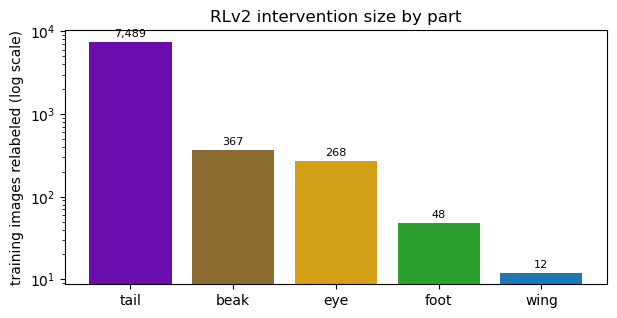

In [3]:
LABEL_CHANGES = pd.Series(
    {"tail": 7489, "beak": 367, "eye": 268, "foot": 48, "wing": 12},
    name="changed_training_images",
).reindex(ORDER)
display(LABEL_CHANGES.to_frame())
fig, ax = plt.subplots(figsize=(7, 3.3))
ax.bar(LABEL_CHANGES.index, LABEL_CHANGES.values,
       color=[COLORS[p] for p in LABEL_CHANGES.index])
ax.set_yscale("log")
ax.set_ylabel("training images relabeled (log scale)")
ax.set_title("RLv2 intervention size by part")
for i, v in enumerate(LABEL_CHANGES):
    ax.text(i, v*1.15, f"{v:,}", ha="center", fontsize=8)
plt.show()


**Literal observation.** Tail receives an intervention one to three orders of magnitude
larger than every other part. This predicts a tail-dominant effect; it does not justify
ignoring beak or eye, whose notebook-02 backwash was also substantial.


## 3 · Did both trainings still produce usable models?

This repeats notebook 02 §1. It is a guard against explaining a grounding change with a
collapsed classifier.

**Prediction.** Task accuracy should remain broadly stable. Accuracy against the old
visibility-blind concept labels may fall and is not, by itself, evidence of damage; the
visibility-aware target is the relevant concept target for RLv2.


,model,labels,epoch,evaluation_population,n,task_acc,concept_acc_against_saved_target
0,CBM,standard,100,funnybirds_processed_trainval,5000,0.7504,0.9944
1,CBM,RLv2,100,funnybirds_processed_rl_trainval,5000,0.7476,0.9966
2,MCBM γ=0,standard,100,funnybirds_processed_trainval,5000,0.7342,0.9903
3,MCBM γ=0,RLv2,100,funnybirds_processed_rl_trainval,5000,0.7496,0.9970
4,MCBM γ=0.1,standard,100,funnybirds_processed_trainval,5000,0.7544,0.9950
5,MCBM γ=0.1,RLv2,100,funnybirds_processed_rl_trainval,5000,0.7474,0.9971


,model,same_training_images_and_classes,same_evaluation_images_and_classes,n_train_standard,n_train_RLv2,n_eval_standard,n_eval_RLv2
0,CBM,True,True,45000,45000,5000,5000
1,MCBM γ=0,True,True,45000,45000,5000,5000
2,MCBM γ=0.1,True,True,45000,45000,5000,5000


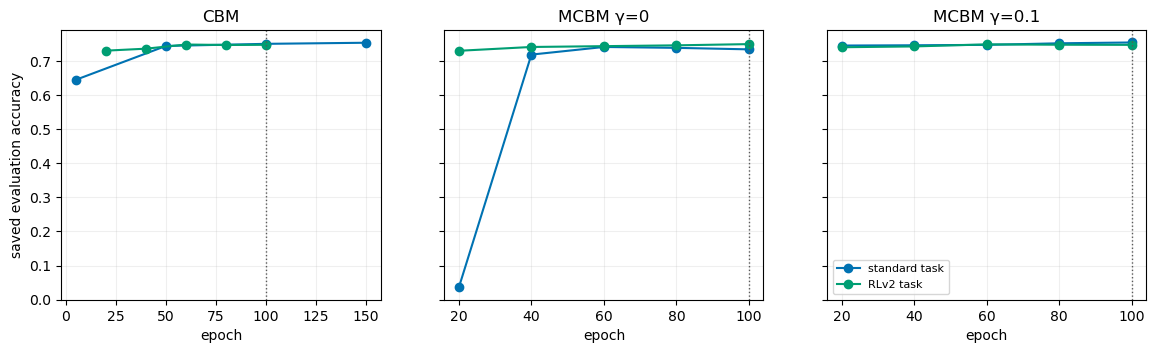

In [4]:
import pickle
import torch
import yaml

PRED_PREFIXES = {
    "CBM": ("funnybirds-cbm", "funnybirds-cbm-rlv2matched"),
    "MCBM γ=0": ("funnybirds-mcbm-g0", "funnybirds-mcbm-rlv2matched-g0"),
    "MCBM γ=0.1": ("funnybirds-mcbm-g0p1", "funnybirds-mcbm-rlv2matched-g0p1"),
}
MATCHED_EPOCH = 100

def configured_records(prefix, split):
    config_path = (
        REPO/"external"/"minimal_cbm"/"configs"/"funnybirds"/f"{prefix}.yaml"
    )
    config = yaml.safe_load(config_path.read_text())
    pkls_dir = Path(config["data"]["pkls_dir"])
    with open(pkls_dir/f"{split}.pkl", "rb") as handle:
        records = pickle.load(handle)
    return pkls_dir, records

def record_identity(record):
    image = record.get("image", record.get("img_path"))
    return str(image).replace("\\", "/"), int(record["class_label"])

def prediction_curve(prefix):
    pred_dir = REPO/"external"/"minimal_cbm"/"results"/prefix/"1"/"predictions"
    files = sorted(
        pred_dir.glob("epoch_*.pth"),
        key=lambda p: int(re.search(r"epoch_(\d+)", p.name).group(1)),
    )
    rows = []
    for path in files:
        d = torch.load(path, map_location="cpu", weights_only=False)
        yp, y = d["y_preds"], d["y"]
        task = (yp.argmax(-1) == y).float().mean().item()
        concept = np.nan
        if d.get("c_preds") is not None and d.get("c") is not None:
            cp = d["c_preds"]
            cp = cp[..., 0] if cp.ndim == 3 else cp
            concept = ((cp >= .5).float() == d["c"]).float().mean().item()
        rows.append((
            int(re.search(r"epoch_(\d+)", path.name).group(1)),
            task, concept, len(y),
        ))
    return pd.DataFrame(rows, columns=["epoch", "task", "concept", "n"])

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)
sanity_rows = []
parity_rows = []
for ax, (model, prefixes) in zip(axes, PRED_PREFIXES.items()):
    populations = {}
    for labels, prefix in zip(["standard", "RLv2"], prefixes):
        curve = prediction_curve(prefix)
        if curve.empty:
            print(f"[pending training sanity] {prefix}")
            continue
        ax.plot(curve.epoch, curve.task, "o-", color=COLORS[labels], label=f"{labels} task")
        exact = curve[curve.epoch == MATCHED_EPOCH]
        if exact.empty:
            print(f"[INVALID] {prefix} lacks epoch {MATCHED_EPOCH}")
            continue
        exact = exact.iloc[0]
        pkls_dir, train_records = configured_records(prefix, "train")
        _, eval_records = configured_records(prefix, "test")
        populations[labels] = {
            "train": [record_identity(r) for r in train_records],
            "evaluation": [record_identity(r) for r in eval_records],
        }
        sanity_rows.append({
            "model": model, "labels": labels,
            "epoch": MATCHED_EPOCH,
            "evaluation_population": pkls_dir.name,
            "n": int(exact["n"]),
            "task_acc": exact.task,
            "concept_acc_against_saved_target": exact.concept,
        })
    if set(populations) == {"standard", "RLv2"}:
        parity_rows.append({
            "model": model,
            "same_training_images_and_classes":
                populations["standard"]["train"] == populations["RLv2"]["train"],
            "same_evaluation_images_and_classes":
                populations["standard"]["evaluation"] == populations["RLv2"]["evaluation"],
            "n_train_standard": len(populations["standard"]["train"]),
            "n_train_RLv2": len(populations["RLv2"]["train"]),
            "n_eval_standard": len(populations["standard"]["evaluation"]),
            "n_eval_RLv2": len(populations["RLv2"]["evaluation"]),
        })
    ax.axvline(MATCHED_EPOCH, color="0.35", ls=":", lw=1)
    ax.set_title(model); ax.set_xlabel("epoch"); ax.grid(alpha=.2)
axes[0].set_ylabel("saved evaluation accuracy")
axes[-1].legend(fontsize=8)
display(pd.DataFrame(sanity_rows).round(4))
TRAINING_PARITY = pd.DataFrame(parity_rows)
display(TRAINING_PARITY)
CAUSAL_TRAINING_PARITY = (
    len(TRAINING_PARITY) == len(PRED_PREFIXES)
    and TRAINING_PARITY[
        ["same_training_images_and_classes", "same_evaluation_images_and_classes"]
    ].to_numpy().all()
)
if not CAUSAL_TRAINING_PARITY:
    print(
        "[INVALID CAUSAL COMPARISON] Standard and RLv2 did not use identical "
        "training/evaluation image populations. Accuracy differences cannot be "
        "interpreted, and downstream RLv2 comparisons are exploratory until "
        "matched models are retrained."
    )
plt.show()


**Discriminating test.** Epoch-100 rows are comparable only when the parity table says
`True` for both training and evaluation identities. A large accuracy change with matching
identities could be a real consequence of relabeling. A change with different identities
is a split confound, not an RLv2 result.

**Limited conclusion rule.** If parity fails, retain later plots only as diagnostics.
Do not call any standard-versus-RLv2 difference causal until RLv2 models are retrained on
the exact standard train/validation membership and reevaluated on the fixed cache.


## 4 · Ordinary-image control, now standard versus RLv2

This repeats notebook 02 §2.

**Question.** Before intervention, does each model still distinguish the present source
concept from the absent donor concept?

**Prediction.** `S_orig` should remain above `D_orig`. RLv2 may lower `S_orig` on
low-visibility originals, so the original image is not an unaffected control.


,model,labels,part,source,absent_donor
0,CBM,standard,tail,10.559,-20.968
1,CBM,standard,beak,14.495,-13.543
2,CBM,standard,eye,11.836,-16.511
3,CBM,standard,foot,17.895,-15.718
4,CBM,standard,wing,12.645,-19.943
5,CBM,RLv2,tail,8.048,-15.268
6,CBM,RLv2,beak,13.286,-13.992
7,CBM,RLv2,eye,13.565,-12.542
8,CBM,RLv2,foot,14.668,-14.627
9,CBM,RLv2,wing,14.672,-14.035


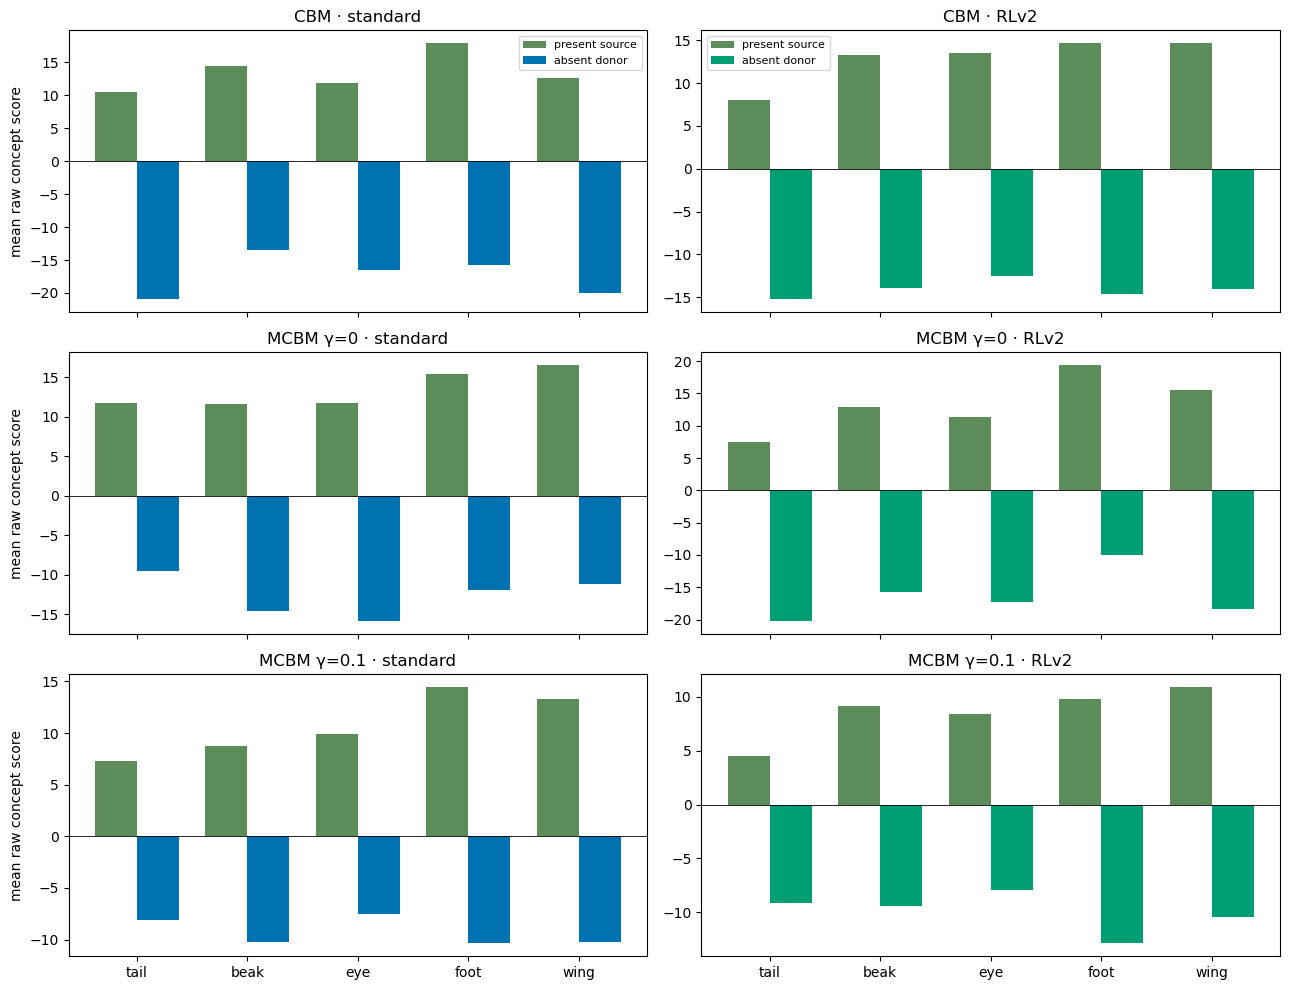

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(13, 10), sharex=True)
ordinary_rows = []
for r, model in enumerate(MODEL_FILES):
    q = PAIRED[model]
    for labels, suffix in [("standard", "standard"), ("RLv2", "rl")]:
        g = q.groupby("part").agg(
            source=(f"z_old_orig_{suffix}", "mean"),
            absent_donor=(f"z_new_orig_{suffix}", "mean"),
        ).reindex(ORDER)
        ordinary_rows.extend(
            dict(model=model, labels=labels, part=p,
                 source=row.source, absent_donor=row.absent_donor)
            for p, row in g.iterrows()
        )
        ax = axes[r, 0 if labels == "standard" else 1]
        x = np.arange(len(g)); w = .38
        ax.bar(x-w/2, g.source, w, color="#5B8C5A", label="present source")
        ax.bar(x+w/2, g.absent_donor, w, color=COLORS[labels], label="absent donor")
        ax.axhline(0, color="k", lw=.6)
        ax.set_title(f"{model} · {labels}")
        ax.set_xticks(x); ax.set_xticklabels(g.index)
axes[0, 0].legend(fontsize=8); axes[0, 1].legend(fontsize=8)
for ax in axes[:, 0]: ax.set_ylabel("mean raw concept score")
display(pd.DataFrame(ordinary_rows).round(3))
plt.tight_layout(); plt.show()


**Decision.** Continue only if the ordinary source remains above the absent donor in every
part. A changed numerical scale is not itself failure; CBM and MCBM raw score scales differ.


## 5 · Intervention validity, copied from notebook 02 and strengthened

Notebook 02 used example triplets and pixel-difference masks. The repaired driver now fails
closed unless the live renderer is deterministic, every target part is visibly present in
the chosen preflight row, swaps/deletions change RGB, and original/swap part maps contain
the target.

The figure below must show, for **every part**, original, swap, deletion, original part map,
and swapped part map. This is a measurement audit, not a model result.


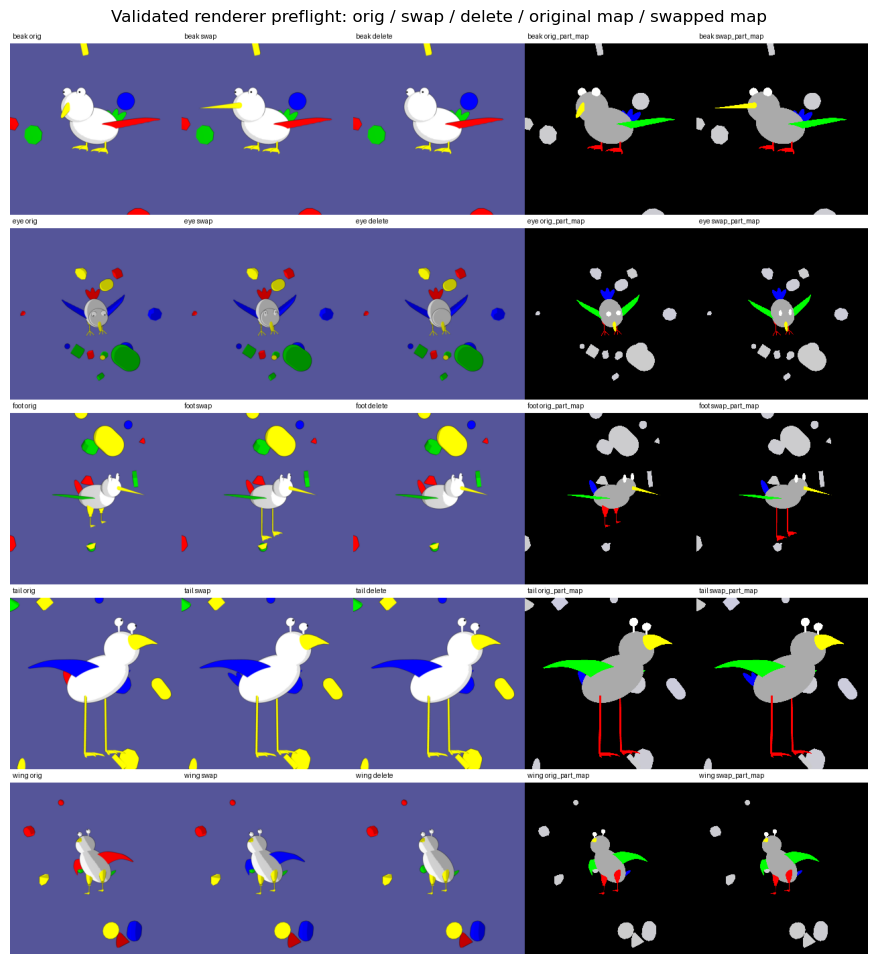

In [6]:
preflight_candidates = [
    SWAP_DIR/"renderer_preflight"/"renderer_semantic_preflight.png",
    SWAP_DIR.parent/"renderer_preflight"/"renderer_semantic_preflight.png",
]
preflight = next((p for p in preflight_candidates if p.exists()), None)
if preflight is None:
    print("[pending display] renderer_semantic_preflight.png was not found beside the fixed run")
else:
    image = mpimg.imread(preflight)
    fig, ax = plt.subplots(figsize=(18, 12))
    ax.imshow(image); ax.axis("off")
    ax.set_title("Validated renderer preflight: orig / swap / delete / original map / swapped map")
    plt.show()


## 6 · Primary result: does the replacement concept beat the removed source?

This directly repeats notebook 02 §4b, but standard and RLv2 share the same renders.

\[
ordering\_correct=\mathbf{1}[D_{swap}-S_{swap}>0].
\]

**Pre-result prediction.** Tail should improve most; beak and eye may improve; foot and wing
should change little. Both swap directions should agree.


,model,part,standard,RLv2,delta,ci_low,ci_high
0,CBM,tail,0.305,0.467,0.162,0.126,0.198
1,CBM,beak,0.460,0.579,0.119,0.077,0.159
2,CBM,eye,0.502,0.565,0.063,0.030,0.096
3,CBM,foot,0.911,0.921,0.010,-0.016,0.034
4,CBM,wing,0.866,0.844,-0.022,-0.053,0.008
5,MCBM γ=0,tail,0.373,0.478,0.105,0.067,0.142
6,MCBM γ=0,beak,0.574,0.509,-0.065,-0.103,-0.026
7,MCBM γ=0,eye,0.500,0.519,0.019,-0.023,0.061
8,MCBM γ=0,foot,0.929,0.899,-0.030,-0.056,-0.005
9,MCBM γ=0,wing,0.857,0.890,0.033,0.009,0.057


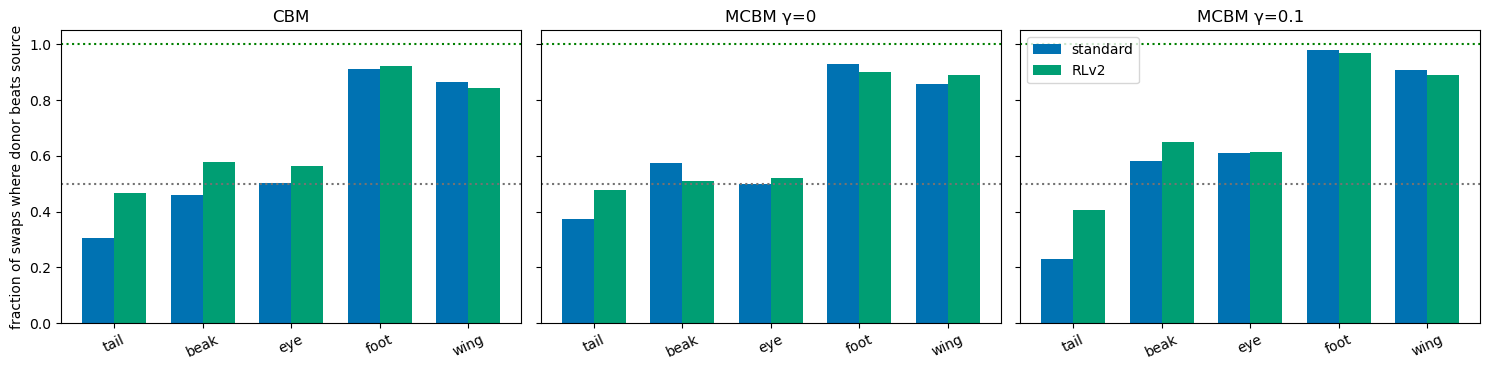

In [7]:
ordering_rows = []
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
for ax, model in zip(axes, MODEL_FILES):
    q = PAIRED[model]
    x = np.arange(len(ORDER)); w = .36
    for off, (labels, suffix) in zip([-.5, .5], [("standard", "standard"), ("RLv2", "rl")]):
        vals = q.groupby("part")[f"ordering_correct_{suffix}"].mean().reindex(ORDER)
        ax.bar(x+off*w, vals, w, color=COLORS[labels], label=labels)
    for part in ORDER:
        d = q[q.part == part].copy()
        d["delta_ordering"] = (
            d.ordering_correct_rl.astype(float)
            - d.ordering_correct_standard.astype(float)
        )
        lo, hi = cluster_ci(d, "delta_ordering")
        ordering_rows.append({
            "model": model, "part": part,
            "standard": d.ordering_correct_standard.mean(),
            "RLv2": d.ordering_correct_rl.mean(),
            "delta": d.delta_ordering.mean(),
            "ci_low": lo, "ci_high": hi,
        })
    ax.axhline(.5, color="0.45", ls=":")
    ax.axhline(1, color="green", ls=":")
    ax.set_xticks(x); ax.set_xticklabels(ORDER, rotation=25)
    ax.set_title(model); ax.set_ylim(0, 1.05)
axes[0].set_ylabel("fraction of swaps where donor beats source")
axes[-1].legend()
ORDERING = pd.DataFrame(ordering_rows)
display(ORDERING.round(3))
plt.tight_layout(); plt.show()


,model,labels,direction,part,ordering
0,CBM,standard,fwd,tail,0.312
1,CBM,standard,fwd,beak,0.400
2,CBM,standard,fwd,eye,0.486
3,CBM,standard,fwd,foot,0.906
4,CBM,standard,fwd,wing,0.880
5,CBM,standard,bwd,tail,0.298
6,CBM,standard,bwd,beak,0.520
7,CBM,standard,bwd,eye,0.518
8,CBM,standard,bwd,foot,0.916
9,CBM,standard,bwd,wing,0.852


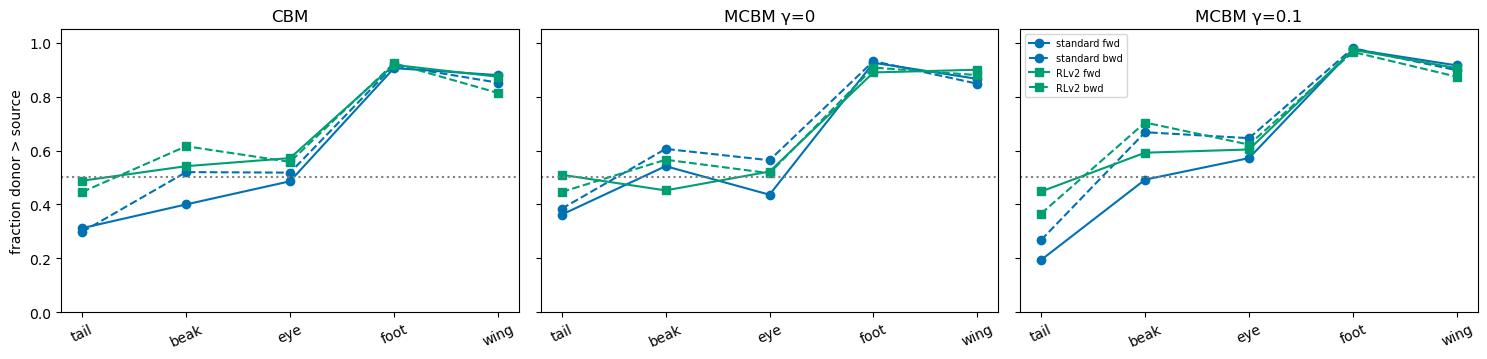

In [8]:
# Direction check: a real result should not exist only for A←B or only for B←A.
direction_rows = []
fig, axes = plt.subplots(1, 3, figsize=(15, 3.7), sharey=True)
for ax, model in zip(axes, MODEL_FILES):
    q = PAIRED[model]
    for labels, suffix, marker in [
        ("standard", "standard", "o"), ("RLv2", "rl", "s")
    ]:
        g = (
            q.groupby(["part", "direction"])[f"ordering_correct_{suffix}"]
            .mean().unstack().reindex(ORDER)
        )
        for direction, ls in [("fwd", "-"), ("bwd", "--")]:
            ax.plot(
                ORDER, g[direction], marker=marker, ls=ls,
                color=COLORS[labels], label=f"{labels} {direction}",
            )
            for part in ORDER:
                direction_rows.append({
                    "model": model, "labels": labels, "direction": direction,
                    "part": part, "ordering": g.loc[part, direction],
                })
    ax.axhline(.5, color=".5", ls=":"); ax.set_ylim(0, 1.05)
    ax.set_title(model); ax.tick_params(axis="x", rotation=25)
axes[0].set_ylabel("fraction donor > source")
axes[-1].legend(fontsize=7)
display(pd.DataFrame(direction_rows).round(3))
plt.tight_layout(); plt.show()


**Literal seed-1 observation.** The table above is the source of truth: tail ordering
increases in every matched comparison, and both directions improve. Beak and eye are not
uniformly rescued; foot and wing remain high but do not consistently improve. This is the
predicted tail-dominant pattern, not a universal RLv2 benefit.

**Next question.** Does that result continue above `γ=0.1`, and does RLv2 move forward and
backward margins together rather than manufacture a cancellation average?


## 6a · Broad `γ` result and the professor-requested direction scatter

This section discovers every matched seed-1 MCBM standard/RLv2 CSV in the validated
fixed-render directory. There is no scientific cutoff at `γ=0.1`: higher `γ` appears as
soon as both checkpoints have been evaluated on the same fixed images.

**Question 1.** Across `γ`, how much does RLv2 change the fraction of swaps where donor
beats source?

**Question 2.** For each `(γ, part)`, do mean forward and backward margins agree? The
original notebook's dot plot put forward margin on x and backward margin on y. The
corrected version below adds an arrow from the standard point to the RLv2 point.

- movement toward the upper-right means improvement in both directions;
- movement along the red anti-diagonal indicates cancellation;
- different arrows across `γ` show whether minimality changes the effect of relabeling.


,gamma,part,standard,RLv2,delta,ci_low,ci_high
0,0.0,tail,0.373,0.478,0.105,0.067,0.142
1,0.0,beak,0.574,0.509,-0.065,-0.103,-0.026
2,0.0,eye,0.500,0.519,0.019,-0.023,0.061
3,0.0,foot,0.929,0.899,-0.030,-0.056,-0.005
4,0.0,wing,0.857,0.890,0.033,0.009,0.057
5,0.1,tail,0.231,0.407,0.176,0.143,0.207
6,0.1,beak,0.580,0.648,0.068,0.028,0.109
7,0.1,eye,0.609,0.613,0.004,-0.039,0.045
8,0.1,foot,0.978,0.970,-0.008,-0.021,0.005
9,0.1,wing,0.907,0.890,-0.017,-0.041,0.008


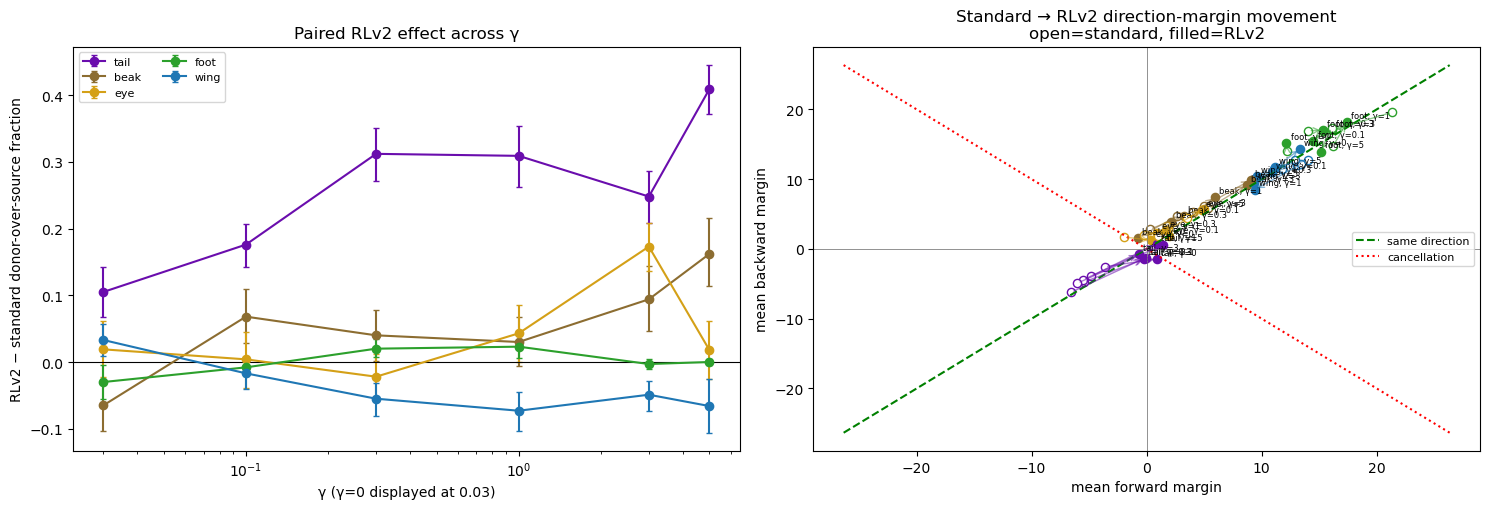

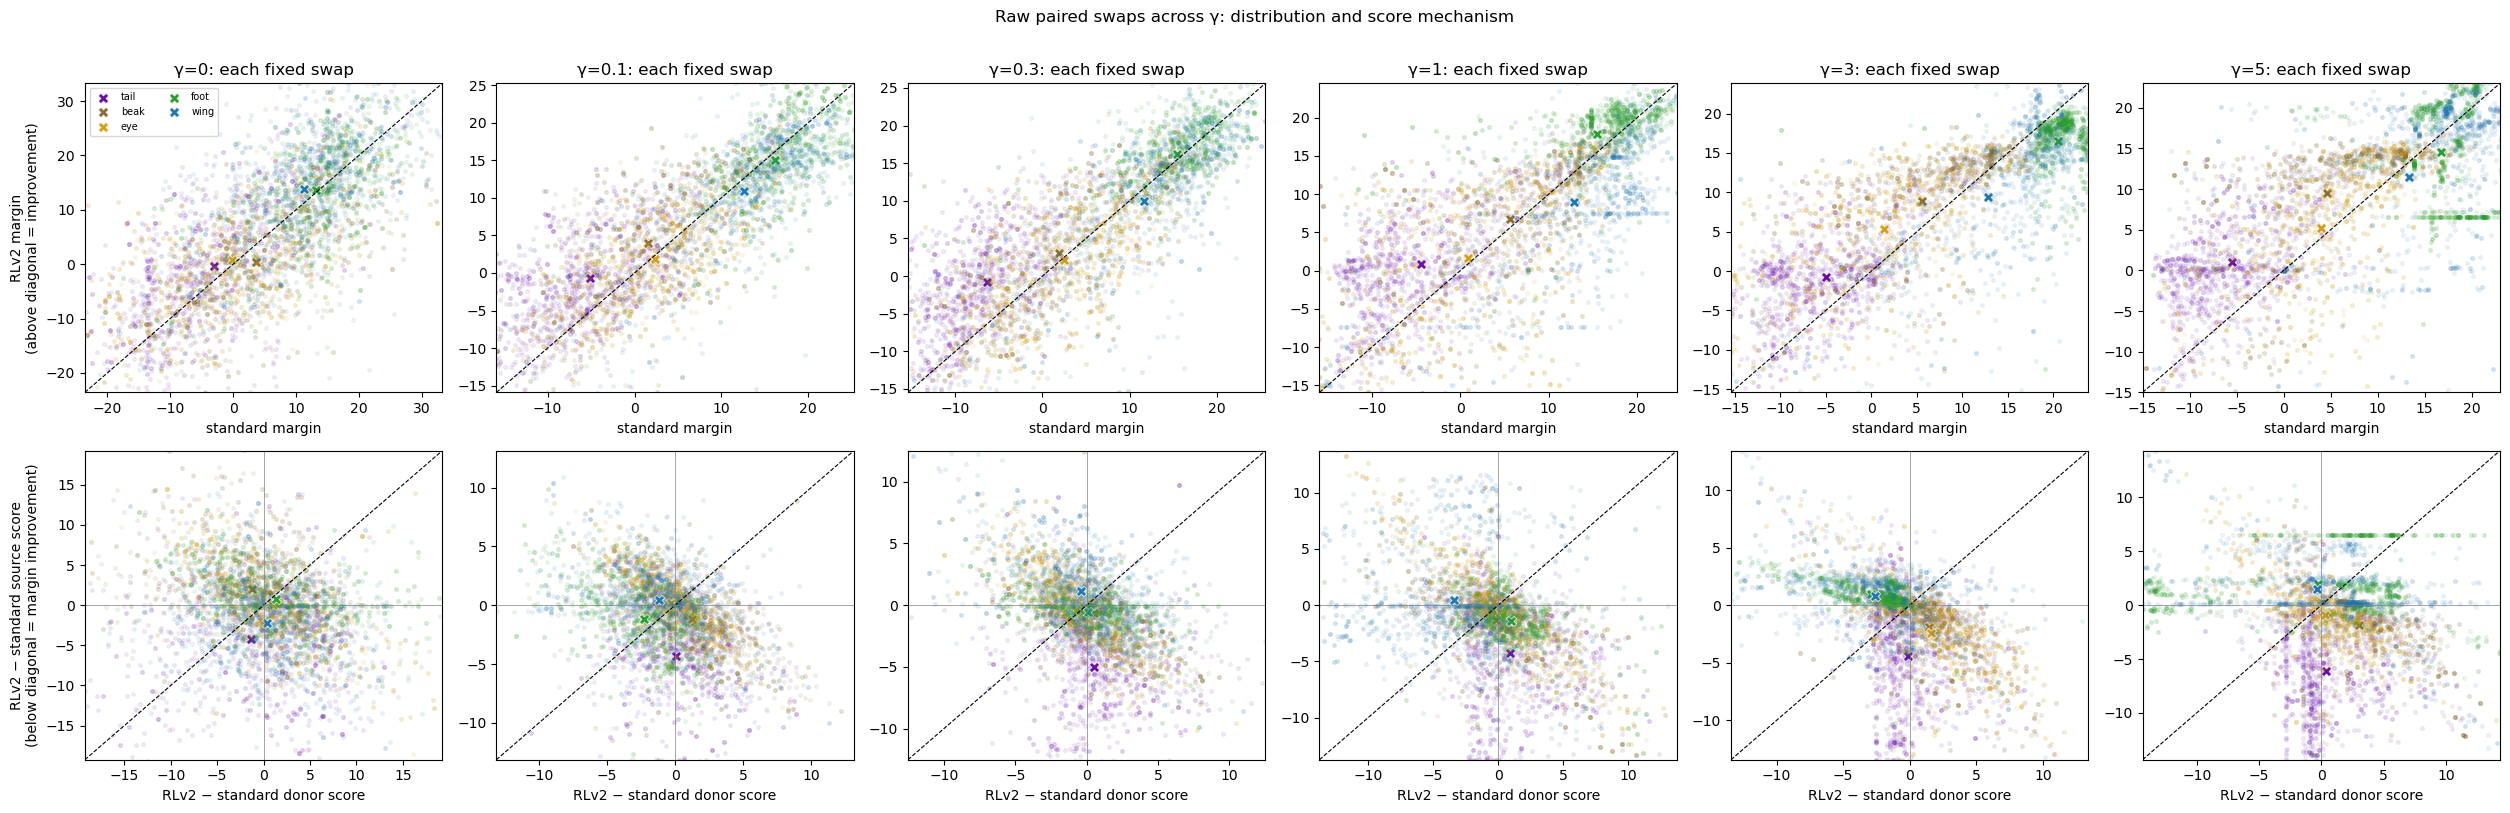

In [9]:
def gamma_from_tag(tag):
    return float(tag.replace("p", "."))

broad_pairs = {}
pattern = re.compile(r"funnybirds-mcbm-g([0-9p]+)-s1\.csv$")
for standard_path in sorted(SWAP_DIR.glob("funnybirds-mcbm-g*-s1.csv")):
    match = pattern.match(standard_path.name)
    if not match:
        continue
    tag = match.group(1)
    rl_path = SWAP_DIR/f"funnybirds-mcbm-rlv2matched-g{tag}-s1.csv"
    if not rl_path.exists():
        continue
    standard = pd.read_csv(standard_path)
    rl = pd.read_csv(rl_path)
    q = standard.merge(
        rl, on="render_id", validate="one_to_one",
        suffixes=("_standard", "_rl"),
    )
    for col in ["image_cf_sha256", "part", "direction", "sid_src", "sid_donor"]:
        if not (q[f"{col}_standard"] == q[f"{col}_rl"]).all():
            raise ValueError(f"broad gamma {tag}: paired column differs: {col}")
        q[col] = q[f"{col}_standard"]
    q["gamma"] = gamma_from_tag(tag)
    q["pair_id"] = q.apply(
        lambda r: f"{r['part']}:{min(r.sid_src,r.sid_donor)}-{max(r.sid_src,r.sid_donor)}",
        axis=1,
    )
    q["delta_ordering"] = (
        q.ordering_correct_rl.astype(float)
        - q.ordering_correct_standard.astype(float)
    )
    broad_pairs[q.gamma.iloc[0]] = q

if broad_pairs:
    broad_rows = []
    for gamma, q in sorted(broad_pairs.items()):
        for part in ORDER:
            d = q[q.part == part]
            lo, hi = cluster_ci(d, "delta_ordering")
            broad_rows.append({
                "gamma": gamma, "part": part,
                "standard": d.ordering_correct_standard.mean(),
                "RLv2": d.ordering_correct_rl.mean(),
                "delta": d.delta_ordering.mean(),
                "ci_low": lo, "ci_high": hi,
            })
    BROAD_GAMMA = pd.DataFrame(broad_rows)
    display(BROAD_GAMMA.round(3))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
    gamma_plot = lambda g: 0.03 if g == 0 else g
    for part in ORDER:
        d = BROAD_GAMMA[BROAD_GAMMA.part == part].sort_values("gamma")
        x = np.array([gamma_plot(g) for g in d.gamma])
        axes[0].errorbar(
            x, d.delta,
            yerr=[d.delta-d.ci_low, d.ci_high-d.delta],
            marker="o", color=COLORS[part], label=part, capsize=2,
        )
    axes[0].axhline(0, color="black", linewidth=.8)
    axes[0].set_xscale("log")
    axes[0].set_xlabel("γ (γ=0 displayed at 0.03)")
    axes[0].set_ylabel("RLv2 − standard donor-over-source fraction")
    axes[0].set_title("Paired RLv2 effect across γ")
    axes[0].legend(fontsize=8, ncol=2)

    ax = axes[1]
    for gamma, q in sorted(broad_pairs.items()):
        for part in ORDER:
            d = q[q.part == part]
            points = {}
            for labels, suffix in [("standard", "standard"), ("RLv2", "rl")]:
                margins = d.groupby("direction")[f"margin_{suffix}"].mean()
                points[labels] = (margins.get("fwd", np.nan), margins.get("bwd", np.nan))
            x0, y0 = points["standard"]
            x1, y1 = points["RLv2"]
            ax.annotate(
                "", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="->", color=COLORS[part], alpha=.55, lw=1),
            )
            ax.scatter(x0, y0, s=35, facecolors="white", edgecolors=COLORS[part])
            ax.scatter(x1, y1, s=35, color=COLORS[part])
            ax.annotate(f"{part}, γ={gamma:g}", (x1, y1), fontsize=6,
                        xytext=(3, 3), textcoords="offset points")
    vals = []
    for q in broad_pairs.values():
        vals.extend(q.margin_standard.tolist())
        vals.extend(q.margin_rl.tolist())
    lim = max(1, np.nanpercentile(np.abs(vals), 99))
    ax.plot([-lim, lim], [-lim, lim], "--", color="green", label="same direction")
    ax.plot([-lim, lim], [lim, -lim], ":", color="red", label="cancellation")
    ax.axhline(0, color="gray", linewidth=.6)
    ax.axvline(0, color="gray", linewidth=.6)
    ax.set_xlabel("mean forward margin")
    ax.set_ylabel("mean backward margin")
    ax.set_title("Standard → RLv2 direction-margin movement\nopen=standard, filled=RLv2")
    ax.legend(fontsize=8)
    fig.tight_layout(); plt.show()

    # Keep one raw-point view because aggregate bars and arrows can hide
    # whether a gain is broad or driven by a small subset of swaps. Row 1
    # pairs each fixed swap's margins; row 2 decomposes the same change.
    gammas = sorted(broad_pairs)
    fig, axes = plt.subplots(
        2, len(gammas), figsize=(4.2*len(gammas), 8), squeeze=False
    )
    for col, gamma in enumerate(gammas):
        q = broad_pairs[gamma]
        ax = axes[0, col]
        for part in ORDER:
            d = q[q.part == part]
            ax.scatter(
                d.margin_standard, d.margin_rl,
                s=7, alpha=.08, color=COLORS[part], rasterized=True,
            )
            ax.scatter(
                d.margin_standard.mean(), d.margin_rl.mean(),
                s=55, marker="X", color=COLORS[part], edgecolor="white",
                linewidth=.5, label=part,
            )
        values = np.r_[q.margin_standard.to_numpy(), q.margin_rl.to_numpy()]
        lo, hi = np.nanpercentile(values, [1, 99])
        ax.plot([lo, hi], [lo, hi], "--", color="black", linewidth=.8)
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        ax.set_title(f"γ={gamma:g}: each fixed swap")
        ax.set_xlabel("standard margin")
        if col == 0:
            ax.set_ylabel("RLv2 margin\n(above diagonal = improvement)")
            ax.legend(fontsize=7, ncol=2)

        ax = axes[1, col]
        q = q.copy()
        q["delta_donor"] = q.z_new_rl - q.z_new_standard
        q["delta_source"] = q.z_old_rl - q.z_old_standard
        for part in ORDER:
            d = q[q.part == part]
            ax.scatter(
                d.delta_donor, d.delta_source,
                s=7, alpha=.08, color=COLORS[part], rasterized=True,
            )
            ax.scatter(
                d.delta_donor.mean(), d.delta_source.mean(),
                s=55, marker="X", color=COLORS[part], edgecolor="white",
                linewidth=.5,
            )
        values = np.r_[q.delta_donor.to_numpy(), q.delta_source.to_numpy()]
        lim = max(1, np.nanpercentile(np.abs(values), 99))
        ax.plot([-lim, lim], [-lim, lim], "--", color="black", linewidth=.8)
        ax.axhline(0, color="gray", linewidth=.5)
        ax.axvline(0, color="gray", linewidth=.5)
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.set_xlabel("RLv2 − standard donor score")
        if col == 0:
            ax.set_ylabel(
                "RLv2 − standard source score\n"
                "(below diagonal = margin improvement)"
            )
    fig.suptitle(
        "Raw paired swaps across γ: distribution and score mechanism", y=1.01
    )
    fig.tight_layout(); plt.show()
else:
    print("[pending] No matched standard/RLv2 MCBM gamma pairs found.")


**Limited conclusion rule.** A positive paired effect or an upper-right arrow supports an
RLv2 improvement at that `γ`. A noisy or non-monotone path means minimality changes the
interaction but does not establish a general trend. Seed 1 can identify the pattern; seeds
2–3 are required before calling the `γ` dependence stable.

**Next question.** Did RLv2 raise the donor, suppress the removed source, or merely rescale
both? The ordering summaries alone cannot answer.


## 7 · Margin distributions: improvement versus full resolution

This repeats notebook 02's margin boxes. A rightward movement shows improvement; values
below zero remain violations.


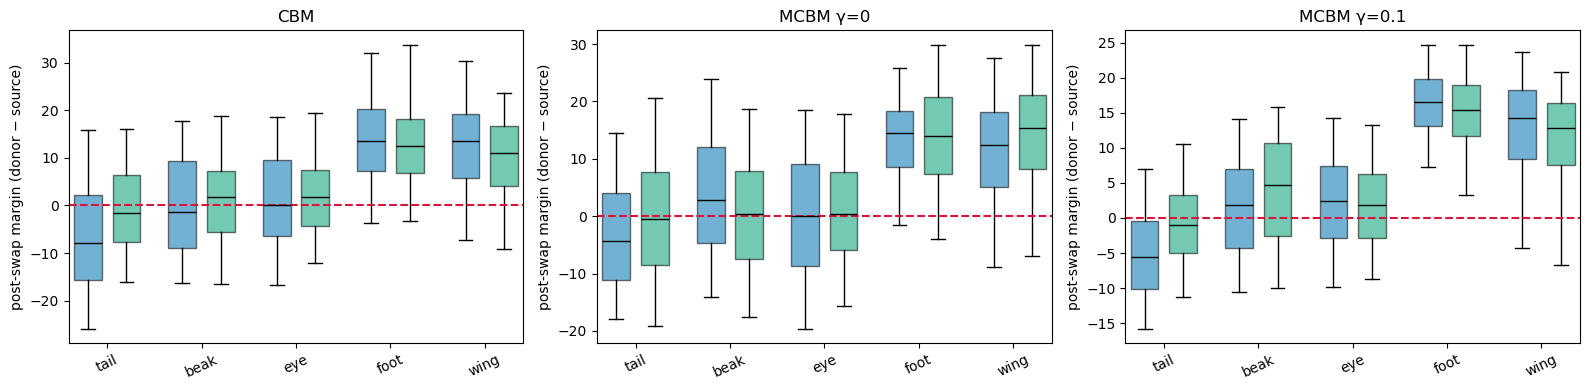

,model,part,standard_margin,RLv2_margin,change
0,CBM,beak,-0.069,1.317,1.386
5,MCBM γ=0,beak,3.691,0.443,-3.248
10,MCBM γ=0.1,beak,1.557,3.967,2.410
1,CBM,eye,1.107,1.963,0.855
6,MCBM γ=0,eye,-0.109,0.821,0.930
11,MCBM γ=0.1,eye,2.358,1.871,-0.487
2,CBM,foot,13.629,13.255,-0.374
7,MCBM γ=0,foot,13.112,13.692,0.580
12,MCBM γ=0.1,foot,16.125,14.969,-1.156
3,CBM,tail,-6.608,-0.617,5.991


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, model in zip(axes, MODEL_FILES):
    q = PAIRED[model]
    positions, values, box_colors, tick_pos, tick_labels = [], [], [], [], []
    pos = 1
    for part in ORDER:
        for labels, suffix in [("standard", "standard"), ("RLv2", "rl")]:
            positions.append(pos); values.append(q.loc[q.part==part, f"margin_{suffix}"])
            box_colors.append(COLORS[labels]); pos += 1
        tick_pos.append(pos-1.5); tick_labels.append(part); pos += .45
    bp = ax.boxplot(values, positions=positions, widths=.72, showfliers=False,
                    whis=(5, 95), patch_artist=True, medianprops={"color":"black"})
    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color); patch.set_alpha(.55)
    ax.axhline(0, color="crimson", ls="--")
    ax.set_xticks(tick_pos); ax.set_xticklabels(tick_labels, rotation=25)
    ax.set_title(model); ax.set_ylabel("post-swap margin (donor − source)")
plt.tight_layout(); plt.show()

margin_summary = []
for model, q in PAIRED.items():
    for part, d in q.groupby("part"):
        margin_summary.append({
            "model": model, "part": part,
            "standard_margin": d.margin_standard.mean(),
            "RLv2_margin": d.margin_rl.mean(),
            "change": (d.margin_rl-d.margin_standard).mean(),
        })
MARGINS = pd.DataFrame(margin_summary)
display(MARGINS.sort_values(["part","model"]).round(3))


**Literal observation.** Tail mean margin moves right in all three models but remains slightly
negative. RLv2 reduces tail backwash; it does not fully resolve it. That residual motivates
the variant and species tests below.


## 8 · Mechanism decomposition: which score changed?

**Prediction.** The most direct effect of visibility-aware supervision is lower `S_swap`:
the removed source should turn off. Cleaner visible positives may also raise `D_swap`, but
that is less certain because RLv2 supplies fewer positive examples.


,model,part,delta_z_new_orig,delta_z_old_orig,delta_z_new,delta_z_old,delta_margin,delta_donor_insertion,delta_source_removal,delta_response
0,CBM,beak,-0.450,-1.209,0.678,-0.708,1.386,1.128,0.501,0.627
1,CBM,eye,3.969,1.729,0.289,-0.566,0.855,-3.680,-2.296,-1.384
2,CBM,foot,1.091,-3.227,-0.524,-0.150,-0.374,-1.615,3.077,-4.692
3,CBM,tail,5.701,-2.511,2.325,-3.665,5.991,-3.375,-1.154,-2.221
4,CBM,wing,5.909,2.026,0.134,2.690,-2.556,-5.774,0.664,-6.438
5,MCBM γ=0,beak,-1.192,1.227,-1.232,2.016,-3.248,-0.040,0.789,-0.830
6,MCBM γ=0,eye,-1.369,-0.458,0.993,0.063,0.930,2.363,0.521,1.842
7,MCBM γ=0,foot,1.857,3.946,1.344,0.763,0.580,-0.513,-3.183,2.670
8,MCBM γ=0,tail,-10.780,-4.372,-1.332,-4.158,2.827,9.448,0.214,9.234
9,MCBM γ=0,wing,-7.253,-0.976,0.355,-2.226,2.580,7.607,-1.250,8.857


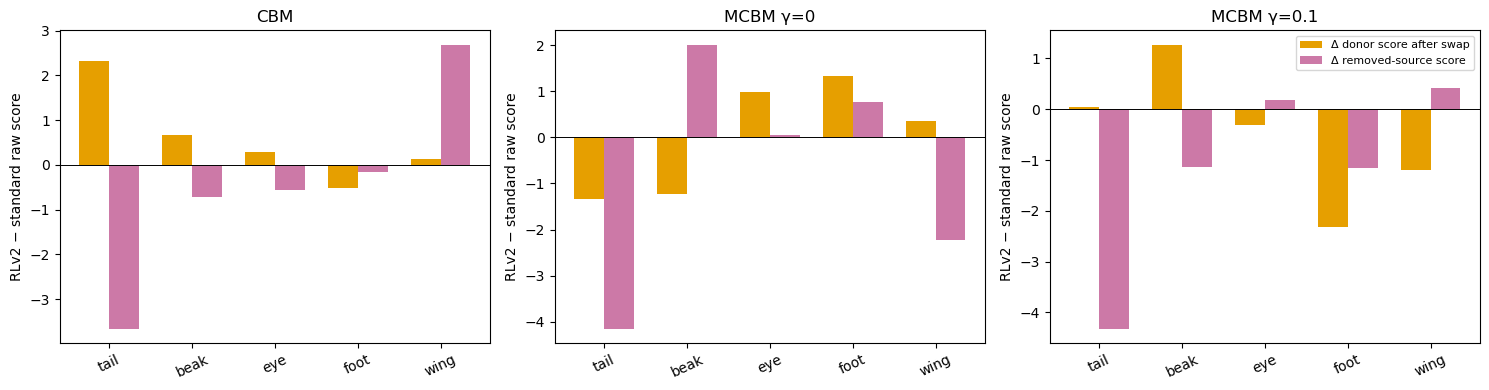

In [11]:
mechanism_rows = []
for model, q in PAIRED.items():
    for part, d in q.groupby("part"):
        row = {"model": model, "part": part}
        for name in ["z_new_orig", "z_old_orig", "z_new", "z_old", "margin"]:
            row[f"delta_{name}"] = (d[f"{name}_rl"]-d[f"{name}_standard"]).mean()
        row["delta_donor_insertion"] = (
            (d.z_new_rl-d.z_new_orig_rl) - (d.z_new_standard-d.z_new_orig_standard)
        ).mean()
        row["delta_source_removal"] = (
            (d.z_old_rl-d.z_old_orig_rl) - (d.z_old_standard-d.z_old_orig_standard)
        ).mean()
        row["delta_response"] = (d.response_delta_rl-d.response_delta_standard).mean()
        mechanism_rows.append(row)
MECH = pd.DataFrame(mechanism_rows)
display(MECH.round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, model in zip(axes, MODEL_FILES):
    g = MECH[MECH.model==model].set_index("part").reindex(ORDER)
    x = np.arange(len(g)); w=.36
    ax.bar(x-w/2, g.delta_z_new, w, color="#E69F00", label="Δ donor score after swap")
    ax.bar(x+w/2, g.delta_z_old, w, color="#CC79A7", label="Δ removed-source score")
    ax.axhline(0,color="k",lw=.7); ax.set_xticks(x); ax.set_xticklabels(ORDER,rotation=25)
    ax.set_title(model); ax.set_ylabel("RLv2 − standard raw score")
axes[-1].legend(fontsize=8)
plt.tight_layout(); plt.show()


**Literal observation.** Tail is the only part whose removed-source score falls in all three
model pairs. Its donor score rises in CBM and MCBM γ=0.1 but falls in MCBM γ=0; source
suppression is therefore the consistent mechanism. Beak follows this pattern in two models.
Eye, foot, and wing are mixed.

**Limited conclusion.** RLv2 performs the operation it was designed for most consistently
on the part that received by far the largest label correction.


## 9 · Secondary test: did insertion/removal sensitivity strengthen?

Notebook 02 already showed that donors usually move in the correct direction. We now compare
the complete original-to-swap contrast:

\[
response_\Delta=margin_{swap}-margin_{orig}.
\]

This is useful but not the primary RLv2 endpoint because `margin_orig` is itself targeted
by visibility-aware relabeling.


,model,part,delta_response,ci_low,ci_high,donorward_standard,donorward_RLv2
0,CBM,tail,-2.221,-3.427,-0.999,0.913,0.899
1,CBM,beak,0.627,-0.486,1.755,0.997,0.996
2,CBM,eye,-1.384,-2.155,-0.632,0.993,0.993
3,CBM,foot,-4.692,-5.705,-3.723,0.995,0.999
4,CBM,wing,-6.438,-7.910,-5.065,0.999,1.000
5,MCBM γ=0,tail,9.234,8.077,10.356,0.878,0.904
6,MCBM γ=0,beak,-0.830,-1.805,0.103,0.989,0.994
7,MCBM γ=0,eye,1.842,0.894,2.753,0.993,0.990
8,MCBM γ=0,foot,2.670,1.504,3.763,0.999,0.997
9,MCBM γ=0,wing,8.857,7.258,10.411,1.000,1.000


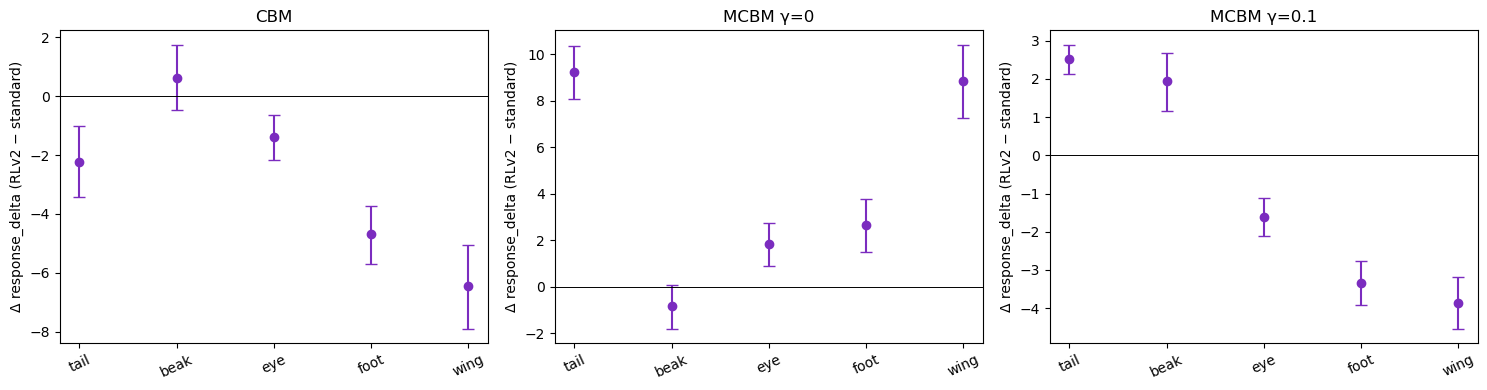

In [12]:
response_rows = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, model in zip(axes, MODEL_FILES):
    q = PAIRED[model]
    points, lows, highs = [], [], []
    for part in ORDER:
        d = q[q.part==part].copy()
        d["delta_response"] = d.response_delta_rl-d.response_delta_standard
        lo, hi = cluster_ci(d, "delta_response")
        points.append(d.delta_response.mean()); lows.append(lo); highs.append(hi)
        response_rows.append({
            "model":model, "part":part, "delta_response":d.delta_response.mean(),
            "ci_low":lo, "ci_high":hi,
            "donorward_standard":d.swap_moved_toward_donor_standard.mean(),
            "donorward_RLv2":d.swap_moved_toward_donor_rl.mean(),
        })
    x=np.arange(len(ORDER)); points=np.array(points)
    ax.errorbar(x, points, yerr=[points-np.array(lows),np.array(highs)-points],
                fmt="o", color="#7B2CBF", capsize=4)
    ax.axhline(0,color="k",lw=.7); ax.set_xticks(x);ax.set_xticklabels(ORDER,rotation=25)
    ax.set_title(model);ax.set_ylabel("Δ response_delta (RLv2 − standard)")
RESPONSE = pd.DataFrame(response_rows)
display(RESPONSE.round(3))
plt.tight_layout();plt.show()


**Literal observation.** Tail `response_delta` is positive in all three comparisons, but the
CBM interval includes zero. Beak has a strong CBM increase. Eye, foot, and wing are
model-dependent. Meanwhile 88–100% of swaps already moved toward the donor before RLv2, so
direction alone was near saturation.

**Interpretation.** RLv2 reliably improves the final tail decision. Evidence that it also
strengthens the entire original-to-swap transition is clear for the two tested MCBMs and
uncertain for CBM.


## 10 · Visibility alternative, repeated for every part

This integrates notebook 02 §5 rather than testing tail alone.

**Questions.**

1. Is RLv2 improvement confined to invisible replacement parts?
2. Among visible replacements, do tail, beak, and eye improve as predicted?
3. Do foot and wing remain stable?

Improvement when `pixel_count_cf=0` cannot be donor-pixel recognition; improvement among
visible bins can be.


,part,vis_bin,delta,ci_low,ci_high,n,species_pairs,standard,RLv2,model
0,beak,0,0.000,0.000,0.000,5,5,0.000,0.000,CBM
1,beak,1–20,0.106,0.022,0.193,123,53,0.276,0.382,CBM
2,beak,21–50,0.104,0.034,0.173,163,77,0.307,0.411,CBM
3,beak,51–100,0.189,0.116,0.267,190,89,0.458,0.647,CBM
4,beak,101–200,0.064,-0.024,0.140,235,93,0.502,0.566,CBM
...,...,...,...,...,...,...,...,...,...,...
97,wing,21–50,-0.056,-0.176,0.000,18,17,0.889,0.833,MCBM γ=0.1
98,wing,51–100,0.054,-0.038,0.156,56,44,0.804,0.857,MCBM γ=0.1
99,wing,101–200,-0.058,-0.122,0.000,121,73,0.868,0.810,MCBM γ=0.1
100,wing,201–500,-0.026,-0.058,0.008,347,100,0.905,0.879,MCBM γ=0.1


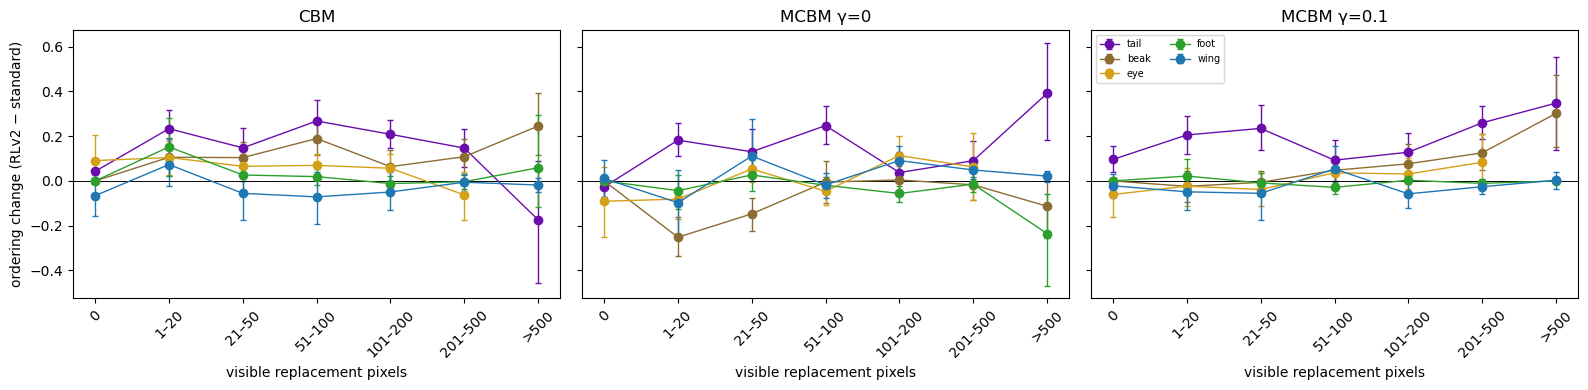

In [13]:
VIS_BINS=[-1,0,20,50,100,200,500,np.inf]
VIS_LABELS=["0","1–20","21–50","51–100","101–200","201–500",">500"]
vis_rows=[]
fig,axes=plt.subplots(1,3,figsize=(16,4),sharey=True)
for ax,model in zip(axes,MODEL_FILES):
    q=PAIRED[model].copy()
    q["vis_bin"]=pd.cut(q.pixel_count_cf_standard,VIS_BINS,labels=VIS_LABELS)
    q["delta_ordering"]=q.ordering_correct_rl.astype(float)-q.ordering_correct_standard.astype(float)
    grouped=[]
    for (part,vis_bin),d in q.groupby(["part","vis_bin"],observed=True):
        lo,hi=cluster_ci(d,"delta_ordering",reps=2000)
        grouped.append({
            "part":part,"vis_bin":vis_bin,
            "delta":d.delta_ordering.mean(),"ci_low":lo,"ci_high":hi,
            "n":len(d),"species_pairs":d.pair_id.nunique(),
            "standard":d.ordering_correct_standard.mean(),
            "RLv2":d.ordering_correct_rl.mean(),
        })
    g=pd.DataFrame(grouped)
    g["model"]=model;vis_rows.append(g)
    for part in ORDER:
        d=(g[g.part==part].set_index("vis_bin")
           .reindex(VIS_LABELS).dropna(subset=["delta"]).reset_index())
        x=np.array([VIS_LABELS.index(str(v)) for v in d.vis_bin])
        ax.errorbar(
            x,d.delta,
            yerr=np.vstack([d.delta-d.ci_low,d.ci_high-d.delta]),
            fmt="o-",capsize=2,label=part,color=COLORS[part],lw=1,
        )
    ax.axhline(0,color="k",lw=.7);ax.set_title(model);ax.tick_params(axis="x",rotation=45)
    ax.set_xticks(range(len(VIS_LABELS)),VIS_LABELS)
    ax.set_xlabel("visible replacement pixels")
axes[0].set_ylabel("ordering change (RLv2 − standard)")
axes[-1].legend(ncol=2,fontsize=7)
VISIBILITY=pd.concat(vis_rows,ignore_index=True)
display(VISIBILITY.round(3))
plt.tight_layout();plt.show()


**How to read this.** Points are seed-1 mean changes. Bars resample source/donor species
pairs rather than treating every reused render row as independent. The table reports both
row count `n` and independent `species_pairs`; bins with few pairs are exploratory.

**Literal seed-1 observation, conditional on training parity.** Tail improves in several
visible bins, not only at zero pixels. The zero-pixel tail group also sometimes improves,
which would implicate source suppression or score calibration alongside donor-pixel
reading. Beak/eye visibility effects vary by model; foot/wing do not show a systematic
RLv2 benefit.

**Next alternative.** Tail remains below ideal even when visible. Does failure concentrate
in specific visual variants?


## 11 · Variant attribution for every part

This combines notebook 02 §6 and §7.

**Prediction.** If RLv2 corrects label conflict but not visual/variant difficulty, donor
attribution should improve overall while particular variants remain poor. A single bad slot
would appear as one isolated row; a broader variant problem appears across several slots.


,model,labels,part,donor_argmax,source_argmax,third_argmax
0,CBM,standard,tail,0.272,0.627,0.101
1,CBM,standard,beak,0.448,0.510,0.042
2,CBM,standard,eye,0.501,0.489,0.010
3,CBM,standard,foot,0.905,0.088,0.007
4,CBM,standard,wing,0.807,0.107,0.086
5,CBM,RLv2,tail,0.419,0.442,0.139
6,CBM,RLv2,beak,0.569,0.396,0.035
7,CBM,RLv2,eye,0.564,0.429,0.007
8,CBM,RLv2,foot,0.917,0.078,0.005
9,CBM,RLv2,wing,0.814,0.126,0.060


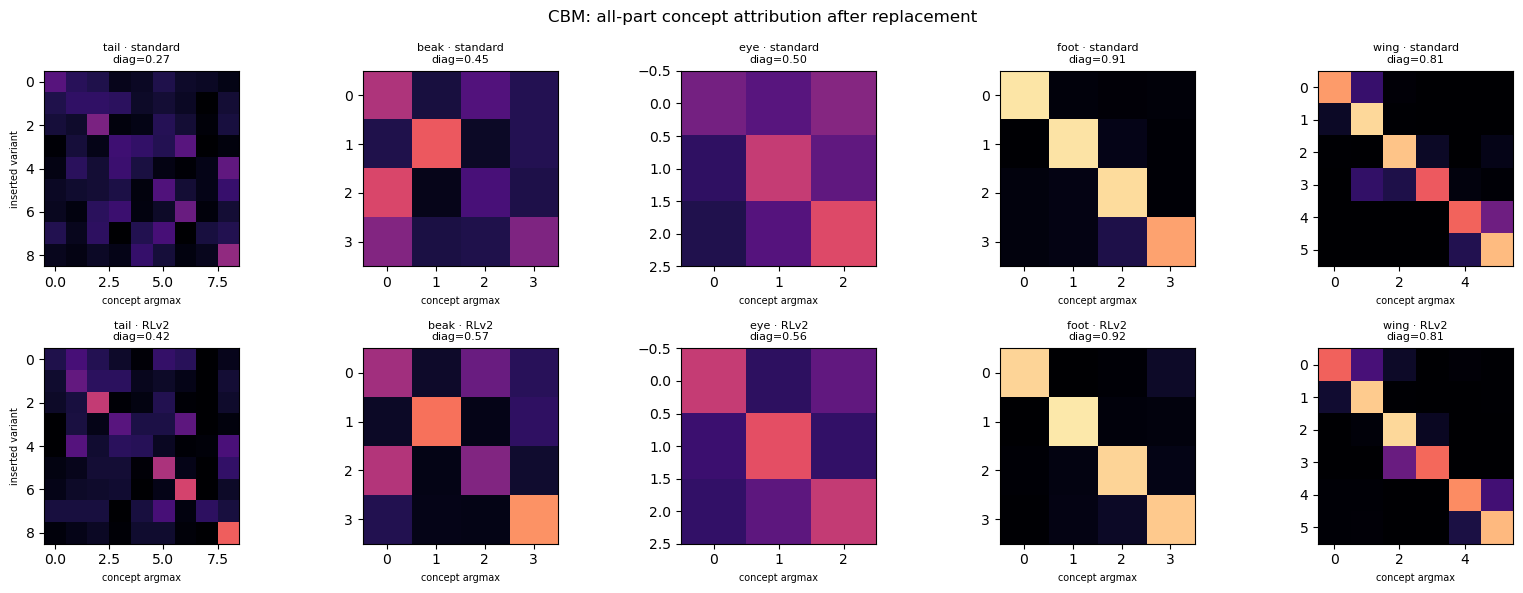

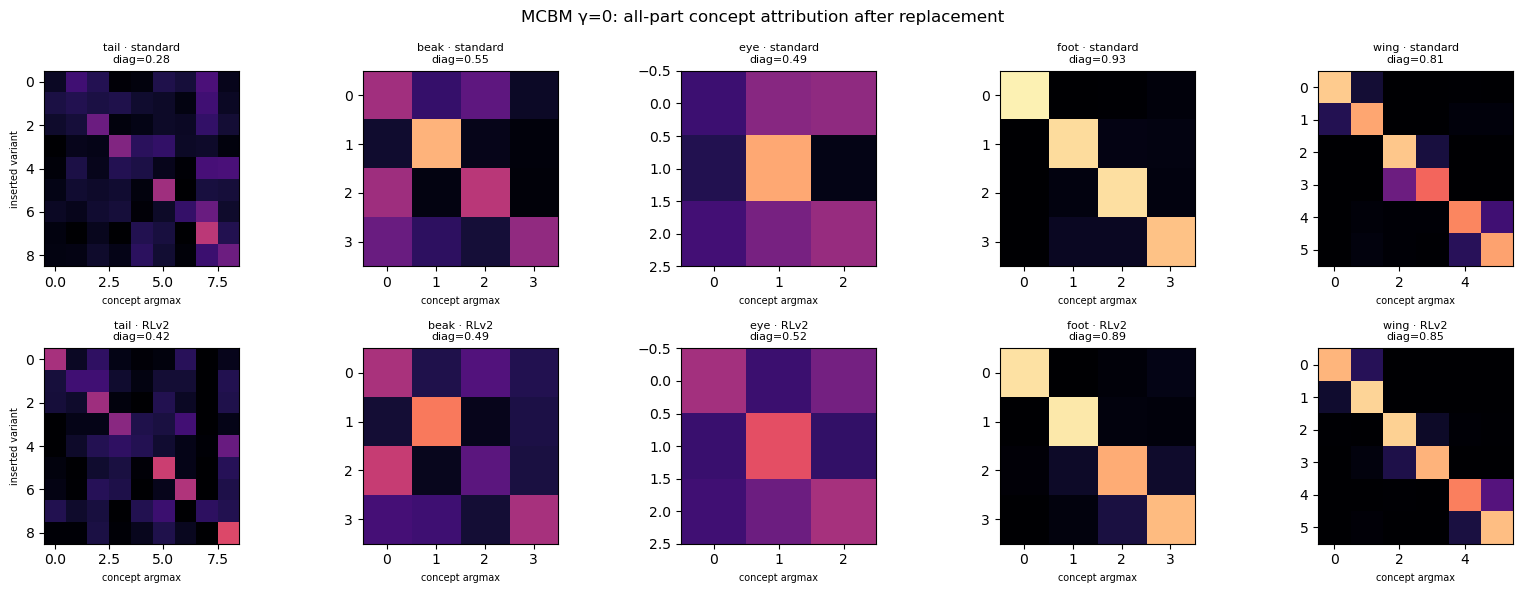

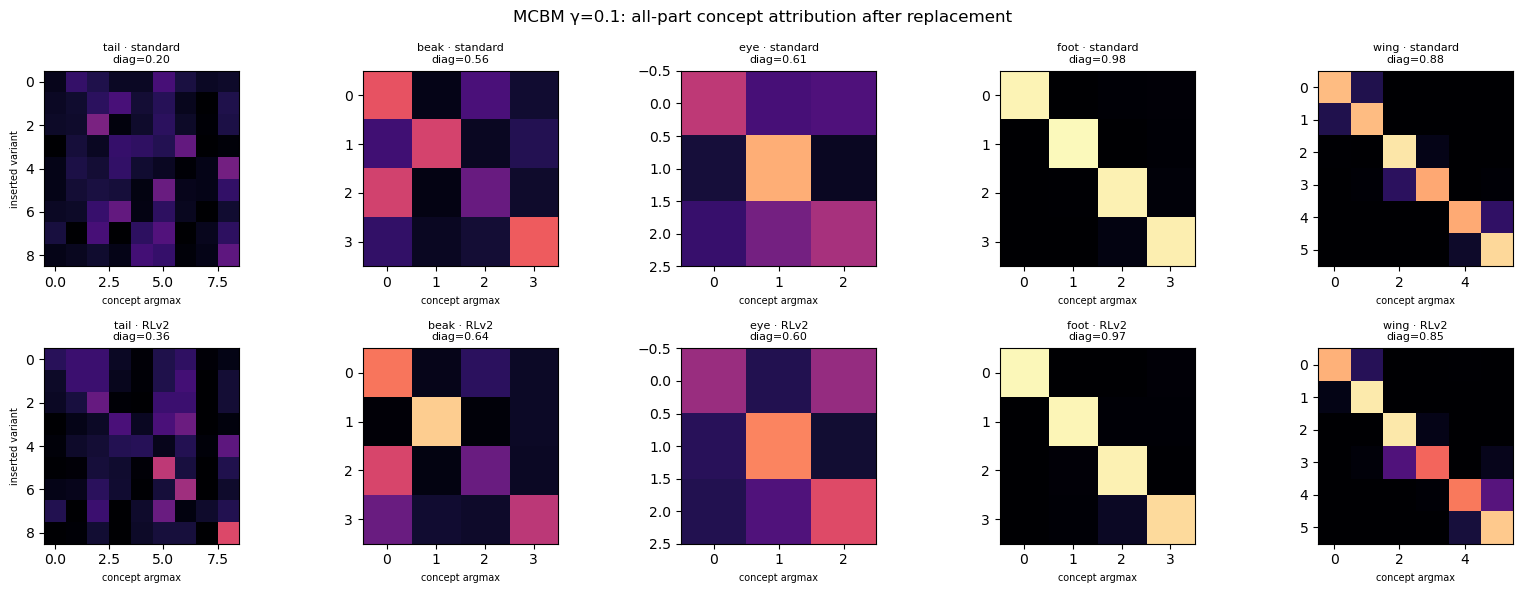

In [14]:
attr_rows=[]
for model in MODEL_FILES:
    for labels in ["standard","RLv2"]:
        d=RAW[(model,labels)]
        for part in ORDER:
            x=d[d.part==part]
            cols=concept_columns(x,part)
            arg=x[cols].to_numpy().argmax(1)
            donor=x.var_donor.to_numpy();source=x.var_src.to_numpy()
            attr_rows.append({
                "model":model,"labels":labels,"part":part,
                "donor_argmax":(arg==donor).mean(),
                "source_argmax":(arg==source).mean(),
                "third_argmax":((arg!=donor)&(arg!=source)).mean(),
            })
ATTR=pd.DataFrame(attr_rows)
display(ATTR.round(3))

for model in MODEL_FILES:
    fig,axes=plt.subplots(2,5,figsize=(16,6))
    for r,labels in enumerate(["standard","RLv2"]):
        d=RAW[(model,labels)]
        for c,part in enumerate(ORDER):
            ax=axes[r,c];x=d[d.part==part];cols=concept_columns(x,part)
            arg=x[cols].to_numpy().argmax(1);donor=x.var_donor.astype(int).to_numpy()
            n=len(cols);M=np.zeros((n,n))
            for a,b in zip(donor,arg):M[a,b]+=1
            M=M/M.sum(1,keepdims=True).clip(min=1)
            ax.imshow(M,cmap="magma",vmin=0,vmax=1)
            ax.set_title(f"{part} · {labels}\ndiag={(arg==donor).mean():.2f}",fontsize=8)
            ax.set_xlabel("concept argmax",fontsize=7)
            if c==0:ax.set_ylabel("inserted variant",fontsize=7)
    fig.suptitle(f"{model}: all-part concept attribution after replacement")
    plt.tight_layout();plt.show()


,model,part,variant,n,standard,RLv2,delta
28,MCBM γ=0,beak,2,190,0.532,0.295,-0.237
54,MCBM γ=0.1,beak,2,190,0.384,0.363,-0.021
2,CBM,beak,2,190,0.268,0.395,0.126
0,CBM,beak,0,345,0.493,0.452,-0.041
26,MCBM γ=0,beak,0,345,0.484,0.472,-0.012
...,...,...,...,...,...,...,...
72,MCBM γ=0.1,wing,0,130,0.915,0.923,0.008
47,MCBM γ=0,wing,1,150,0.880,0.940,0.060
22,CBM,wing,2,220,0.905,0.941,0.036
74,MCBM γ=0.1,wing,2,220,0.964,0.968,0.005


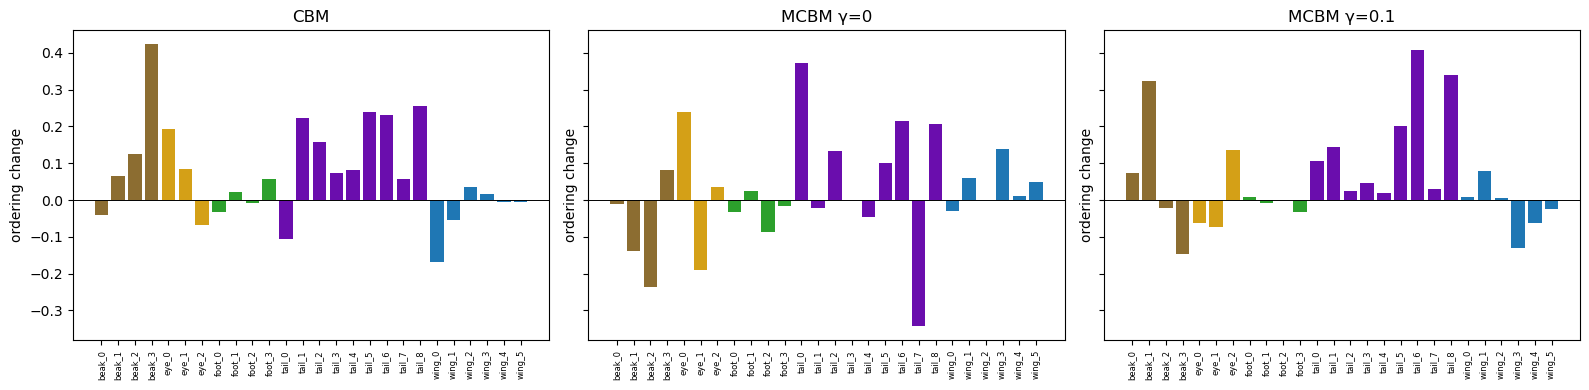

In [15]:
# Every donor variant, not tail alone.
variant_rows=[]
for model,q in PAIRED.items():
    for (part,var),d in q.groupby(["part","var_donor"]):
        variant_rows.append({
            "model":model,"part":part,"variant":int(var),"n":len(d),
            "standard":d.ordering_correct_standard.mean(),
            "RLv2":d.ordering_correct_rl.mean(),
            "delta":(d.ordering_correct_rl.astype(float)-d.ordering_correct_standard.astype(float)).mean(),
        })
VARIANTS=pd.DataFrame(variant_rows)
display(VARIANTS.sort_values(["part","RLv2"]).round(3))

fig,axes=plt.subplots(1,3,figsize=(16,4),sharey=True)
for ax,model in zip(axes,MODEL_FILES):
    d=VARIANTS[VARIANTS.model==model].copy()
    labels=[f"{p}_{v}" for p,v in zip(d.part,d.variant)]
    ax.bar(np.arange(len(d)),d.delta,color=[COLORS[p] for p in d.part])
    ax.axhline(0,color="k",lw=.7);ax.set_xticks(np.arange(len(d)))
    ax.set_xticklabels(labels,rotation=90,fontsize=6);ax.set_title(model)
    ax.set_ylabel("ordering change")
plt.tight_layout();plt.show()


,model,part,var_src,var_donor,n,standard,RLv2,delta
137,MCBM γ=0,beak,3,2,40,0.925,0.375,-0.550
136,MCBM γ=0,beak,3,1,70,0.900,0.557,-0.343
257,MCBM γ=0.1,beak,1,3,70,0.800,0.500,-0.300
135,MCBM γ=0,beak,3,0,110,0.773,0.536,-0.236
127,MCBM γ=0,beak,0,2,105,0.267,0.105,-0.162
...,...,...,...,...,...,...,...,...
230,MCBM γ=0,wing,1,4,30,0.767,0.933,0.167
234,MCBM γ=0,wing,2,3,35,0.514,0.714,0.200
250,MCBM γ=0,wing,5,3,25,0.720,1.000,0.280
103,CBM,wing,1,3,15,0.467,0.867,0.400


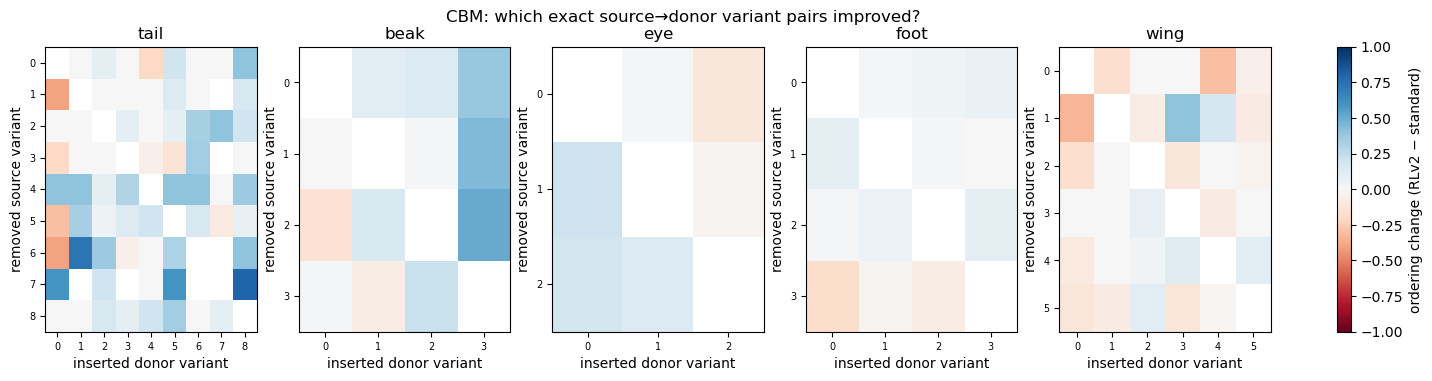

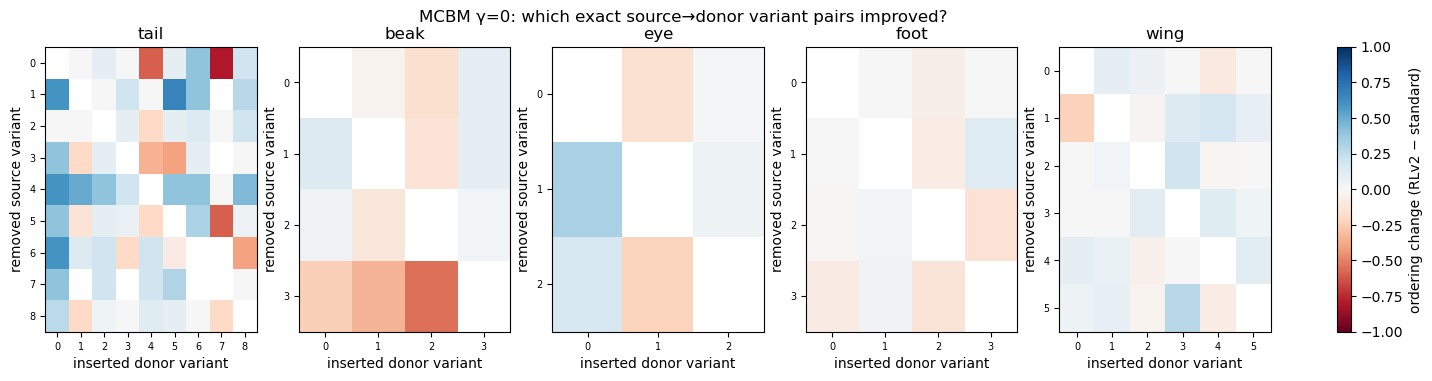

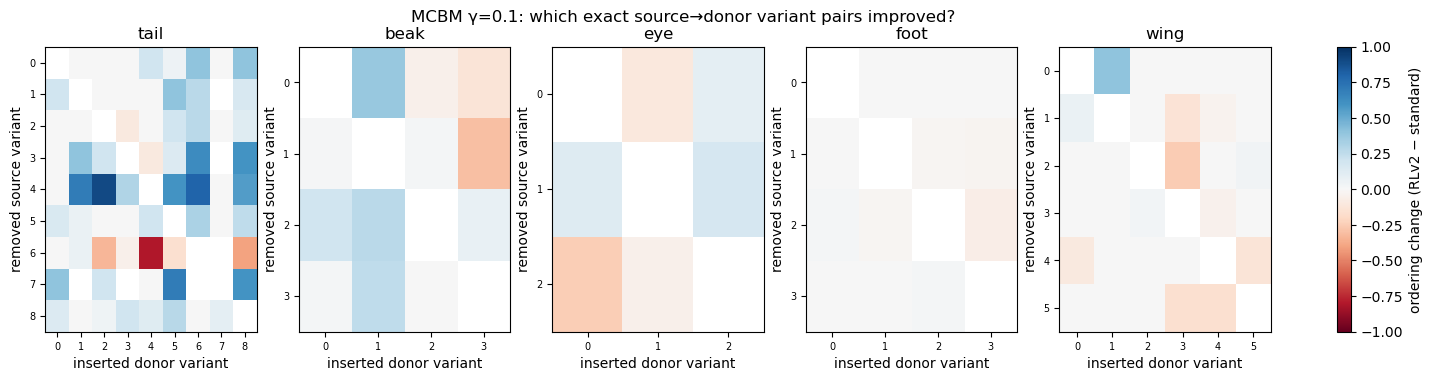

In [16]:
# Source-variant × donor-variant matrices for every part.
# Each cell is the paired change in ordering, so positive means RLv2 helped that exact
# visual combination and negative means it hurt.
pair_variant_rows=[]
for model,q in PAIRED.items():
    for (part,var_src,var_donor),d in q.groupby(["part","var_src","var_donor"]):
        pair_variant_rows.append({
            "model":model,"part":part,"var_src":int(var_src),"var_donor":int(var_donor),
            "n":len(d),
            "standard":d.ordering_correct_standard.mean(),
            "RLv2":d.ordering_correct_rl.mean(),
            "delta":(
                d.ordering_correct_rl.astype(float)
                - d.ordering_correct_standard.astype(float)
            ).mean(),
        })
VARIANT_PAIRS=pd.DataFrame(pair_variant_rows)
display(VARIANT_PAIRS.sort_values(["part","delta"]).round(3))

for model in MODEL_FILES:
    fig,axes=plt.subplots(1,5,figsize=(17,3.7))
    for ax,part in zip(axes,ORDER):
        d=VARIANT_PAIRS[(VARIANT_PAIRS.model==model)&(VARIANT_PAIRS.part==part)]
        H=d.pivot(index="var_src",columns="var_donor",values="delta")
        im=ax.imshow(H,cmap="RdBu",vmin=-1,vmax=1,aspect="auto")
        ax.set_title(part);ax.set_xlabel("inserted donor variant")
        ax.set_ylabel("removed source variant")
        ax.set_xticks(range(len(H.columns)));ax.set_xticklabels(H.columns,fontsize=7)
        ax.set_yticks(range(len(H.index)));ax.set_yticklabels(H.index,fontsize=7)
    fig.colorbar(im,ax=axes,fraction=.02,label="ordering change (RLv2 − standard)")
    fig.suptitle(f"{model}: which exact source→donor variant pairs improved?")
    plt.show()


**Literal observation.** Tail donor attribution rises and removed-source attribution falls
in all three models, but tail variants remain highly unequal. `tail_7` remains extremely
poor while `tail_6` and `tail_8` often improve strongly. Beak and eye contain their own
difficult variants; foot and wing remain mostly high.

**Limited conclusion.** RLv2 corrects a broad tail tendency but not all visual categories.
The remaining failure is not explained by one corrupted tail slot.

**Next alternative.** Because every species owns a fixed canonical variant, raw
per-species failure can merely restate variant difficulty. We must condition on source
variant, donor variant, direction, and visibility before asking whether the unchanged body
still matters.


## 12 · Does source species still matter after variant and visibility controls?

For each model, label regime, and part:

1. Form strata with the same source variant, donor variant, direction, and visibility bin.
2. Subtract each stratum's mean ordering from every row.
3. Average the remaining residual by source species.
4. Compare the residual species spread with shuffling source-species labels within strata.

A remaining association is compatible with body/species context, but it can also include
stable source-image or pose differences. It is not, by itself, proof of a semantic species
lookup.


,model,labels,part,controlled_rows,species,residual_species_spread,permutation_p
0,CBM,standard,beak,935,46,0.0300,0.004
1,CBM,standard,eye,989,50,0.0407,0.004
2,CBM,standard,foot,931,45,0.0085,0.004
3,CBM,standard,tail,388,30,0.0270,0.004
4,CBM,standard,wing,698,46,0.0060,0.004
5,CBM,RLv2,beak,935,46,0.0312,0.004
6,CBM,RLv2,eye,989,50,0.0450,0.004
7,CBM,RLv2,foot,931,45,0.0105,0.004
8,CBM,RLv2,tail,388,30,0.0167,0.004
9,CBM,RLv2,wing,698,46,0.0097,0.004


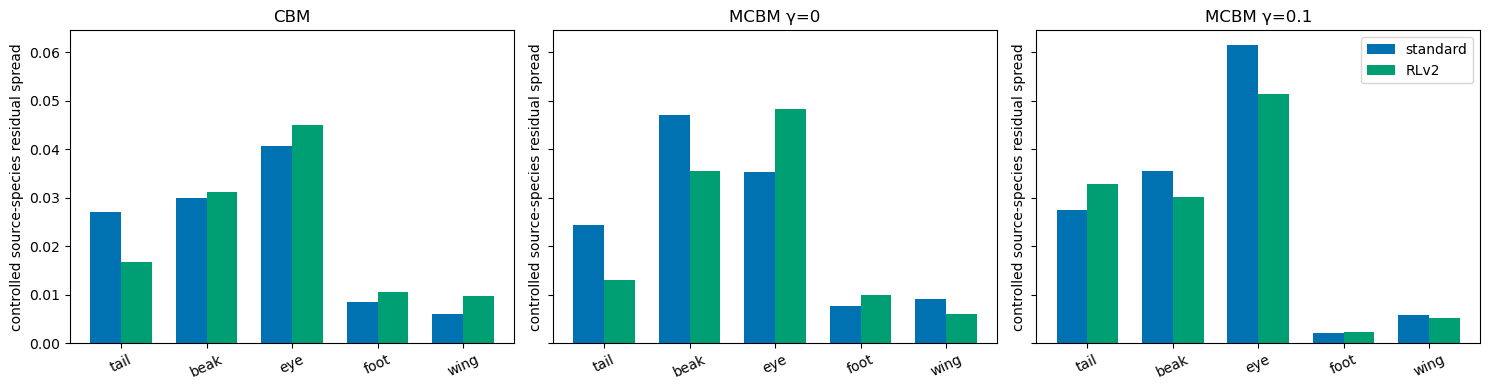

In [17]:
def species_residuals(frame,outcome,reps=250,seed=20260730):
    d=frame.copy()
    d["vis_bin"]=pd.cut(d.pixel_count_cf_standard,VIS_BINS,labels=VIS_LABELS)
    controls=["var_src","var_donor","direction","vis_bin"]
    d["stratum"]=d[controls].astype(str).agg("|".join,axis=1)
    sizes=d.groupby("stratum").size()
    species=d.groupby("stratum").sid_src.nunique()
    keep=sizes[(sizes>=4)&(species>=2)].index
    d=d[d.stratum.isin(keep)].copy()
    d["expected"]=d.groupby("stratum")[outcome].transform("mean")
    d["residual"]=d[outcome]-d.expected
    by=d.groupby("sid_src").residual.agg(["mean","size"]).query("size>=5")
    spread=np.average(by["mean"]**2,weights=by["size"]) if len(by) else np.nan
    # Shuffle source-species labels only within matched control strata. Numpy bincount
    # keeps this fast enough to run transparently in the notebook.
    species_code,species_values=pd.factorize(d.sid_src,sort=True)
    stratum_code,_=pd.factorize(d.stratum,sort=True)
    stratum_indices=[np.flatnonzero(stratum_code==i) for i in np.unique(stratum_code)]
    residual=d.residual.to_numpy()
    rng=np.random.default_rng(seed)
    perm=np.empty(reps)
    for b in range(reps):
        shuffled=species_code.copy()
        for idx in stratum_indices:
            shuffled[idx]=rng.permutation(shuffled[idx])
        counts=np.bincount(shuffled,minlength=len(species_values))
        sums=np.bincount(shuffled,weights=residual,minlength=len(species_values))
        good=counts>=5
        means=np.divide(sums,counts,out=np.zeros_like(sums),where=counts>0)
        perm[b]=np.average(means[good]**2,weights=counts[good])
    p=(1+(perm>=spread).sum())/(reps+1)
    return d,by,spread,p

species_rows=[];residual_tables={}
for model,q in PAIRED.items():
    for labels,outcome in [
        ("standard","ordering_correct_standard"),("RLv2","ordering_correct_rl")
    ]:
        for part,d in q.groupby("part"):
            used,by,spread,p=species_residuals(
                d,outcome,seed=20260730+len(species_rows)
            )
            residual_tables[(model,labels,part)]=by
            species_rows.append({
                "model":model,"labels":labels,"part":part,
                "controlled_rows":len(used),"species":len(by),
                "residual_species_spread":spread,"permutation_p":p,
            })
SPECIES_RESIDUAL=pd.DataFrame(species_rows)
display(SPECIES_RESIDUAL.round(4))

fig,axes=plt.subplots(1,3,figsize=(15,4),sharey=True)
for ax,model in zip(axes,MODEL_FILES):
    d=SPECIES_RESIDUAL[SPECIES_RESIDUAL.model==model]
    x=np.arange(len(ORDER));w=.36
    for off,labels in [(-.5,"standard"),(.5,"RLv2")]:
        g=d[d.labels==labels].set_index("part").reindex(ORDER)
        ax.bar(x+off*w,g.residual_species_spread,w,color=COLORS[labels],label=labels)
    ax.set_xticks(x);ax.set_xticklabels(ORDER,rotation=25);ax.set_title(model)
    ax.set_ylabel("controlled source-species residual spread")
axes[-1].legend();plt.tight_layout();plt.show()


**Literal observation.** Source-species residual structure remains after these controls for
every part. For tail, RLv2 reduces the residual spread slightly in all three models but does
not remove it. For other parts, changes are mixed.

**Alternative explanations still alive:** unchanged body/species context, stable pose or
camera differences by source image, residual visibility measurement error, and visual
similarity among variants. The aggregate CSV cannot visually distinguish these.

Therefore the next cell does not speculate. It repeats the controlled residual analysis
on high-visibility rows, selects the worst remaining RLv2 source species for **each part**,
and displays an actual original/counterfactual example with its part map.


## 13 · Inspect the unexplained examples—for every part

This is an explanatory probe, not statistical proof. For each part, select the model/source
species with the most negative controlled residual **among high-visibility replacements**,
then display the original, swapped image, and swapped part map with the source/donor
variants, visible pixels, and RLv2 margin.

“High visibility” is defined separately for each part as at least the median positive
replacement-pixel count, and never fewer than eight pixels. This prevents a zero-pixel
no-op from being presented as an unexplained failure.

Look for: near-identical variants, extreme pose, body overlap, truncation, or renderer
geometry. Do not write a visual explanation until the images and part maps are displayed.


High-visibility thresholds: {'tail': 95, 'beak': 104, 'eye': 57, 'foot': 134, 'wing': 403}


,part,model,sid_src,controlled_residual,var_src,var_donor,visibility_threshold,visible_pixels,margin_RLv2
0,tail,MCBM γ=0.1,36,-0.381,8,2,95,258,-10.400
1,beak,MCBM γ=0,26,-0.792,0,1,104,236,-19.160
2,eye,MCBM γ=0.1,36,-0.619,2,0,57,58,-3.846
3,foot,CBM,45,-0.500,3,0,134,137,-8.923
4,wing,CBM,22,-0.232,5,3,403,483,-8.879


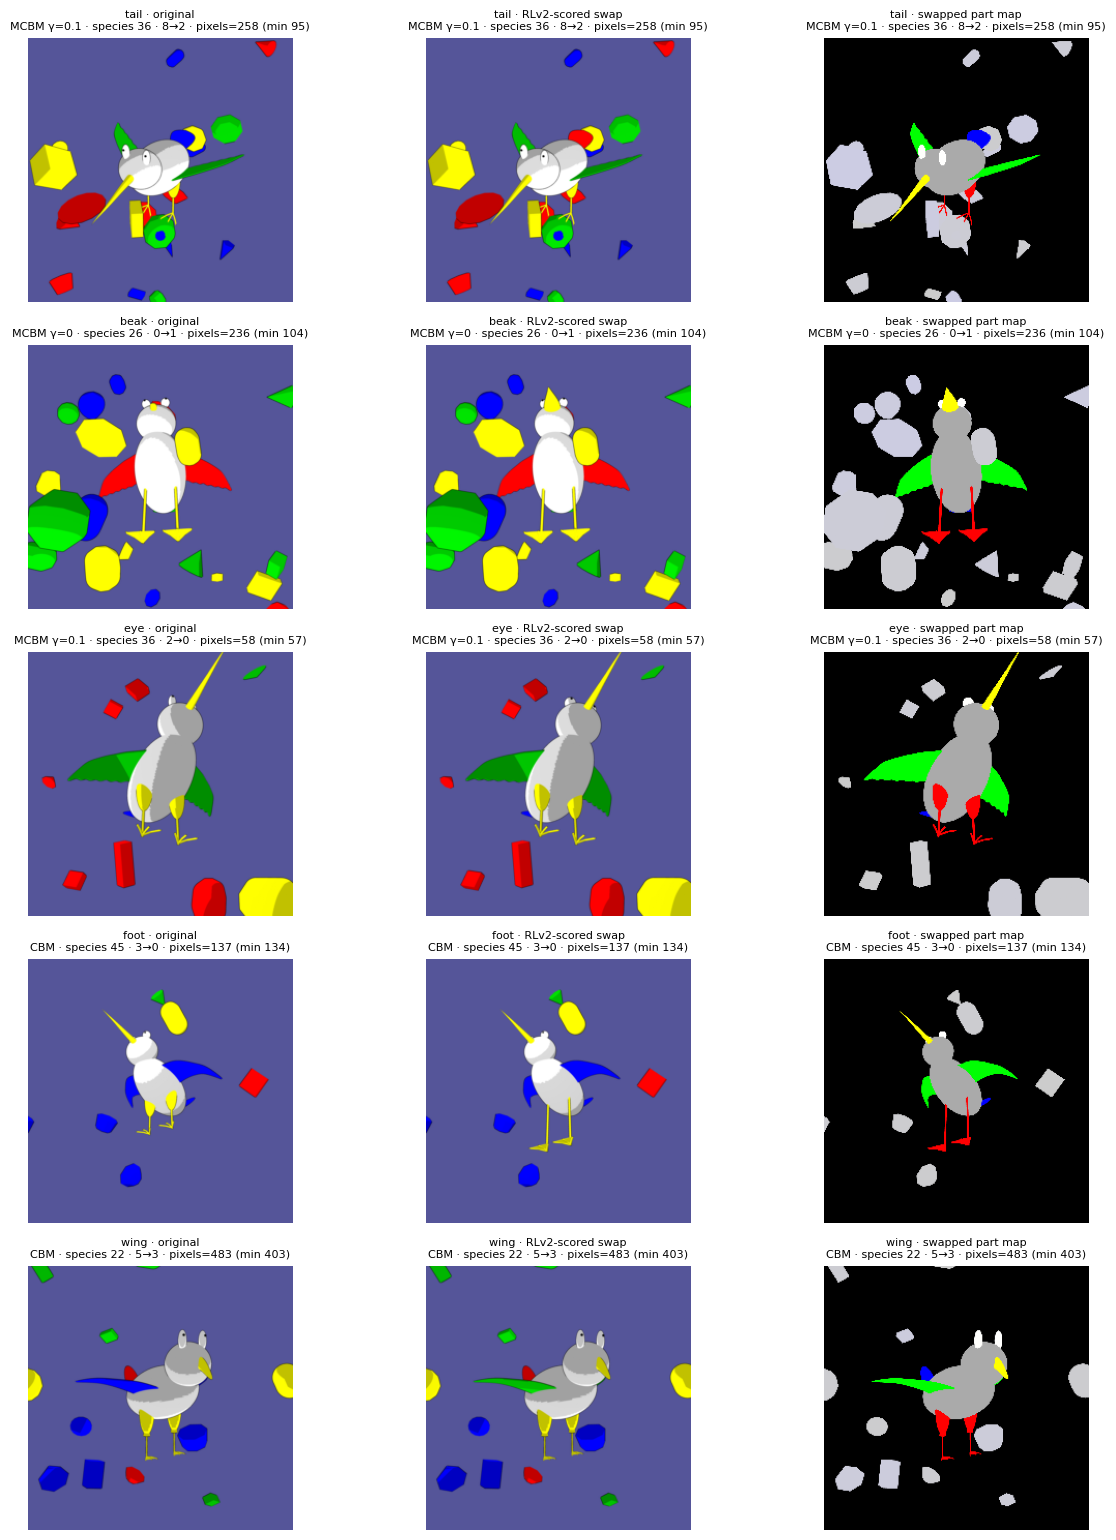

In [18]:
reference_visibility=PAIRED[next(iter(MODEL_FILES))]
visibility_thresholds={
    part:max(
        8,
        int(reference_visibility.loc[
            (reference_visibility.part==part)
            & (reference_visibility.pixel_count_cf_standard>0),
            "pixel_count_cf_standard",
        ].median()),
    )
    for part in ORDER
}
print("High-visibility thresholds:",visibility_thresholds)

worst=[]
for part in ORDER:
    candidates=[]
    threshold=visibility_thresholds[part]
    for model in MODEL_FILES:
        q=PAIRED[model]
        high=q[
            (q.part==part)
            & (q.pixel_count_cf_standard>=threshold)
        ].copy()
        _,by,_,_=species_residuals(
            high,"ordering_correct_rl",reps=250,
            seed=20260730+ORDER.index(part),
        )
        if len(by):
            sid=int(by["mean"].idxmin())
            candidates.append((float(by.loc[sid,"mean"]),model,sid))
    if not candidates:
        raise RuntimeError(
            f"No controlled high-visibility species candidate for {part}; "
            "refusing to substitute an occluded example."
        )
    residual,model,sid=min(candidates)
    q=PAIRED[model]
    d=q[
        (q.part==part)&(q.sid_src==sid)
        &(q.pixel_count_cf_standard>=threshold)
    ].copy()
    row=d.sort_values("margin_rl").iloc[0]
    # v3 evaluations may reuse a validated cache outside SWAP_DIR. The
    # recorded RGB path identifies the cache that actually produced this row.
    rgb_path=Path(row.image_cf_path_rl)
    partmap_path=rgb_path.parent.parent/"part_map"/f"{row.render_id}.png"
    worst.append({
        "part":part,"model":model,"sid_src":sid,"controlled_residual":residual,
        "var_src":int(row.var_src),"var_donor":int(row.var_donor),
        "visibility_threshold":threshold,
        "visible_pixels":int(row.pixel_count_cf_standard),
        "margin_RLv2":row.margin_rl,
        "original_path":row.image_orig_path_rl,
        "swap_path":row.image_cf_path_rl,
        "partmap_path":str(partmap_path),
    })
WORST_EXAMPLES=pd.DataFrame(worst)
if not (WORST_EXAMPLES.visible_pixels>=WORST_EXAMPLES.visibility_threshold).all():
    raise RuntimeError("Visible-only example selection failed closed")
display(WORST_EXAMPLES.drop(
    columns=["original_path","swap_path","partmap_path"]
).round(3))

fig,axes=plt.subplots(len(ORDER),3,figsize=(13,3.1*len(ORDER)))
for r,row in WORST_EXAMPLES.iterrows():
    for c,(name,path_col) in enumerate([
        ("original","original_path"),
        ("RLv2-scored swap","swap_path"),
        ("swapped part map","partmap_path"),
    ]):
        ax=axes[r,c];path=Path(row[path_col])
        if path.exists():ax.imshow(mpimg.imread(path))
        else:ax.text(.5,.5,f"missing image\n{path}",ha="center",va="center")
        ax.axis("off")
        ax.set_title(
            f"{row['part']} · {name}\n{row['model']} · species {row.sid_src} · "
            f"{row.var_src}→{row.var_donor} · pixels={row.visible_pixels} "
            f"(min {row.visibility_threshold})",
            fontsize=8,
        )
plt.tight_layout();plt.show()


## 14 · Independent deletion test

This repeats notebook 02 §3 with standard and RLv2 checkpoints for **every part**.

**Prediction.** If concepts became more dependent on their pixels, deleting a visibly present
part should leave a smaller

\[
retained\_frac=\frac{\mathbb{E}[p_{removed}]}{\mathbb{E}[p_{intact}]}.
\]

Exclude no-op deletions with `changed_frac<=0`. Agreement with the swap result would
independently support the mechanism.


In [19]:
def load_grounding(pattern):
    rows=[]
    for path in sorted((CURATED_DATA/"grounding").glob(pattern)):
        d=pd.read_parquet(path)
        m=re.search(r"-s(\d+)",path.stem)
        d["seed"]=int(m.group(1)) if m else np.nan
        rows.append(d)
    return pd.concat(rows,ignore_index=True) if rows else None

deletion_rows=[]
deletion_specs=[
    ("CBM","standard","funnybirds-cbm-s*.parquet"),
    ("CBM","RLv2","funnybirds-cbm-rlv2matched-s*.parquet"),
    ("MCBM γ=0","standard","funnybirds-mcbm-g0-s*.parquet"),
    ("MCBM γ=0","RLv2","funnybirds-mcbm-rlv2matched-g0-s*.parquet"),
    ("MCBM γ=0.1","standard","funnybirds-mcbm-g0p1-s*.parquet"),
    ("MCBM γ=0.1","RLv2","funnybirds-mcbm-rlv2matched-g0p1-s*.parquet"),
]
for model,labels,pattern in deletion_specs:
    d=load_grounding(pattern)
    if d is None:continue
    if "changed_frac" in d:d=d[d.changed_frac>0]
    for (seed,part),x in d.groupby(["seed","part"]):
        deletion_rows.append({
            "model":model,"labels":labels,"seed":seed,"part":part,
            "retained_frac":x.p_removed.mean()/x.p_intact.mean(),
            "n":len(x),
        })
DELETION=pd.DataFrame(deletion_rows)
if DELETION.empty or not (DELETION.labels=="RLv2").any():
    print("[PENDING] No RLv2 deletion parquet exists. Do not claim independent confirmation.")
else:
    display(DELETION.round(3))
    fig,axes=plt.subplots(1,3,figsize=(15,4),sharey=True)
    for ax,model in zip(axes,MODEL_FILES):
        d=DELETION[DELETION.model==model]
        x=np.arange(len(ORDER));w=.36
        for off,labels in [(-.5,"standard"),(.5,"RLv2")]:
            g=d[d.labels==labels].groupby("part").retained_frac.mean().reindex(ORDER)
            ax.bar(x+off*w,g,w,color=COLORS[labels],label=labels)
        ax.set_xticks(x);ax.set_xticklabels(ORDER,rotation=25);ax.set_title(model)
        ax.set_ylabel("retained fraction (lower = more pixel-dependent)")
    axes[-1].legend();plt.tight_layout();plt.show()


[PENDING] No RLv2 deletion parquet exists. Do not claim independent confirmation.


## 15 · Is species information reduced inside each part block?

This repeats notebook 02 §9 for every part. It is different from grounding: a concept can
follow its pixels while the full pattern still encodes species.

**Prediction.** If RLv2 reduces context shortcuts, species predictability from tail concepts
should decrease most, beak/eye may decrease, and foot/wing should change little.


In [20]:
probe_rows=[]
for path in sorted((CURATED_DATA/"species_probe").glob("funnybirds-*.json")):
    name=path.stem
    if "rlv2" not in name and not any(
        token in name for token in ["funnybirds-cbm-s","funnybirds-mcbm-g0-s","funnybirds-mcbm-g0p1-s"]
    ):
        continue
    d=json.loads(path.read_text())
    labels="RLv2" if "rlv2" in name else "standard"
    model=("CBM" if "cbm-s" in name
           else "MCBM γ=0.1" if "g0p1" in name else "MCBM γ=0")
    for part,v in d["species_from_part_cpreds"].items():
        probe_rows.append({
            "model":model,"labels":labels,"part":part,
            "species_accuracy":v["acc"],"chance":d["chance"],
        })
PROBE=pd.DataFrame(probe_rows)
if PROBE.empty or not (PROBE.labels=="RLv2").any():
    print("[PENDING] Corrected RLv2 species probes are missing.")
else:
    display(PROBE.round(3))
    fig,axes=plt.subplots(1,3,figsize=(15,4),sharey=True)
    for ax,model in zip(axes,MODEL_FILES):
        d=PROBE[PROBE.model==model]
        x=np.arange(len(ORDER));w=.36
        for off,labels in [(-.5,"standard"),(.5,"RLv2")]:
            g=d[d.labels==labels].groupby("part").species_accuracy.mean().reindex(ORDER)
            ax.bar(x+off*w,g,w,color=COLORS[labels],label=labels)
        ax.set_xticks(x);ax.set_xticklabels(ORDER,rotation=25);ax.set_title(model)
        ax.set_ylabel("species accuracy from one part block")
    axes[-1].legend();plt.tight_layout();plt.show()


[PENDING] Corrected RLv2 species probes are missing.


## 16 · Downstream effect, for every part

Notebook 02 found that concept-layer backwash usually had only a small species-head effect.

**Prediction.** Better donor-over-source ordering may slightly increase donor-species
probability, but task-level change is not required for the concept-grounding hypothesis.


,model,part,standard,RLv2,change
0,CBM,beak,0.0208,0.0178,-0.0030
1,CBM,eye,0.0178,0.0160,-0.0018
2,CBM,foot,0.0406,0.0408,0.0002
3,CBM,tail,0.0160,0.0199,0.0039
4,CBM,wing,0.0549,0.0599,0.0050
5,MCBM γ=0,beak,0.0259,0.0205,-0.0054
6,MCBM γ=0,eye,0.0186,0.0122,-0.0064
7,MCBM γ=0,foot,0.0353,0.0350,-0.0003
8,MCBM γ=0,tail,0.0137,0.0227,0.0091
9,MCBM γ=0,wing,0.0496,0.0540,0.0044


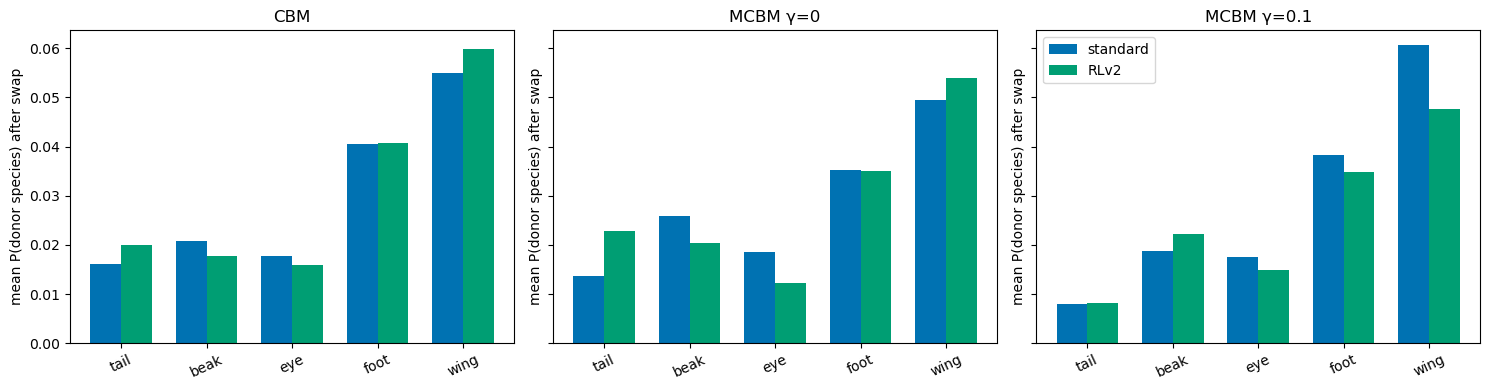

In [21]:
downstream=[]
for model,q in PAIRED.items():
    for part,d in q.groupby("part"):
        downstream.append({
            "model":model,"part":part,
            "standard":d.p_cf_donor_standard.mean(),
            "RLv2":d.p_cf_donor_rl.mean(),
            "change":(d.p_cf_donor_rl-d.p_cf_donor_standard).mean(),
        })
DOWNSTREAM=pd.DataFrame(downstream)
display(DOWNSTREAM.round(4))
fig,axes=plt.subplots(1,3,figsize=(15,4),sharey=True)
for ax,model in zip(axes,MODEL_FILES):
    d=DOWNSTREAM[DOWNSTREAM.model==model].set_index("part").reindex(ORDER)
    x=np.arange(len(d));w=.36
    ax.bar(x-w/2,d.standard,w,color=COLORS["standard"],label="standard")
    ax.bar(x+w/2,d.RLv2,w,color=COLORS["RLv2"],label="RLv2")
    ax.set_xticks(x);ax.set_xticklabels(ORDER,rotation=25);ax.set_title(model)
    ax.set_ylabel("mean P(donor species) after swap")
axes[-1].legend();plt.tight_layout();plt.show()


**Literal observation.** Tail donor-species probability rises slightly in all three models,
but remains only about 1–3%. Other parts are mixed. RLv2 primarily changes the concept layer;
these data do not support a large task-level effect.


## 17 · Integrated conclusion and next discriminating questions

### Conditional seed-1 pattern

The following statements are admissible only when `CAUSAL_TRAINING_PARITY=True`. If it is
false, they describe the old diagnostic comparison and do **not** establish an RLv2 effect.

1. The matched-render comparison shows higher tail donor-over-source ordering in CBM,
   MCBM γ=0, and MCBM γ=0.1.
2. Tail is the only part whose removed-source score consistently falls across all three.
3. Tail donor attribution rises and source anchoring falls in all three.
4. Improvement exists among visibly rendered tails, so it is not solely a zero-pixel artifact.
5. Beak shows partial support; eye is model-dependent; foot and wing show no systematic gain.
6. Tail remains below 50% ordering and far below the ideal near 100%; RLv2 reduces rather than
   eliminates backwash.
7. Residual failure varies strongly by tail variant and controlled source species.
8. Downstream species-probability effects remain small.

### What remains unproved

- Training-population parity: must pass before any RLv2 difference is called causal.
- Training-seed reproducibility: evaluate seeds 2 and 3 on the same cache.
- Independent deletion confirmation: RLv2 grounding parquets are still missing.
- Reduced species coding: corrected RLv2 species probes are still missing.
- Full γ behavior: standard high-γ context must be completed before optional high-γ RLv2.
- Visual explanation of the worst controlled species: inspect the example grid above before
  naming geometry, occlusion, or visual similarity.

### Next question

If deletion confirms stronger pixel dependence but specific variants/species remain poor,
RLv2 has isolated label conflict as one cause while leaving variant geometry/body context as
a second cause. The next controlled intervention should then hold source body fixed and
compare multiple donor variants with matched visibility—or randomize body/species context
while preserving the same visible part—not merely train another γ.


## Provenance

Discovery plots and ordering come from notebook 02 and the original FunnyBirds renderer
notebooks. The RLv2 intervention was motivated by notebook 02's visibility alternative.
The fixed-render audit, source/donor decomposition, paired response diagnostic,
all-part standard-versus-RLv2 confusion grids, controlled source-species residual analysis,
and worst-example selection are the causal follow-up added here.


## Predicate-first decision gate

Before calling a negative post-swap margin backwash, require both:

1. `response_delta > 0`: the inserted donor pixels moved the model toward the donor;
2. `margin_after_swap < 0`: despite that response, the old source still wins.

Model health, semantic renderer validity, forward/backward agreement, fixed image
hashes, and seed scope are separate prerequisites. See
`../PREDICATE_PROOF_LEDGER.md`. A visibility filter is a selection check, not a
causal subtraction. The matched RLv2 comparison is the causal subtraction.


,model,part,n_all,standard_rate_all,n_high_visibility,standard_rate_high_visibility,rl_rate_same_high_visibility,resolved_1_to_0,introduced_0_to_1,remaining_1_to_1,remaining_count
0,CBM,beak,1000,0.537,500,0.434,0.330,0.218,0.114,0.216,108
1,CBM,eye,1000,0.491,494,0.449,0.397,0.154,0.101,0.296,146
2,CBM,foot,1000,0.084,501,0.052,0.062,0.034,0.044,0.018,9
3,CBM,tail,1000,0.608,409,0.535,0.359,0.230,0.054,0.306,125
4,CBM,wing,1000,0.133,457,0.072,0.096,0.033,0.057,0.039,18
5,MCBM γ=0,beak,1000,0.415,500,0.348,0.362,0.122,0.136,0.226,113
6,MCBM γ=0,eye,1000,0.493,494,0.464,0.443,0.180,0.160,0.283,140
7,MCBM γ=0,foot,1000,0.070,501,0.050,0.098,0.028,0.076,0.022,11
8,MCBM γ=0,tail,1000,0.506,409,0.416,0.333,0.203,0.120,0.213,87
9,MCBM γ=0,wing,1000,0.143,457,0.112,0.079,0.055,0.022,0.057,26


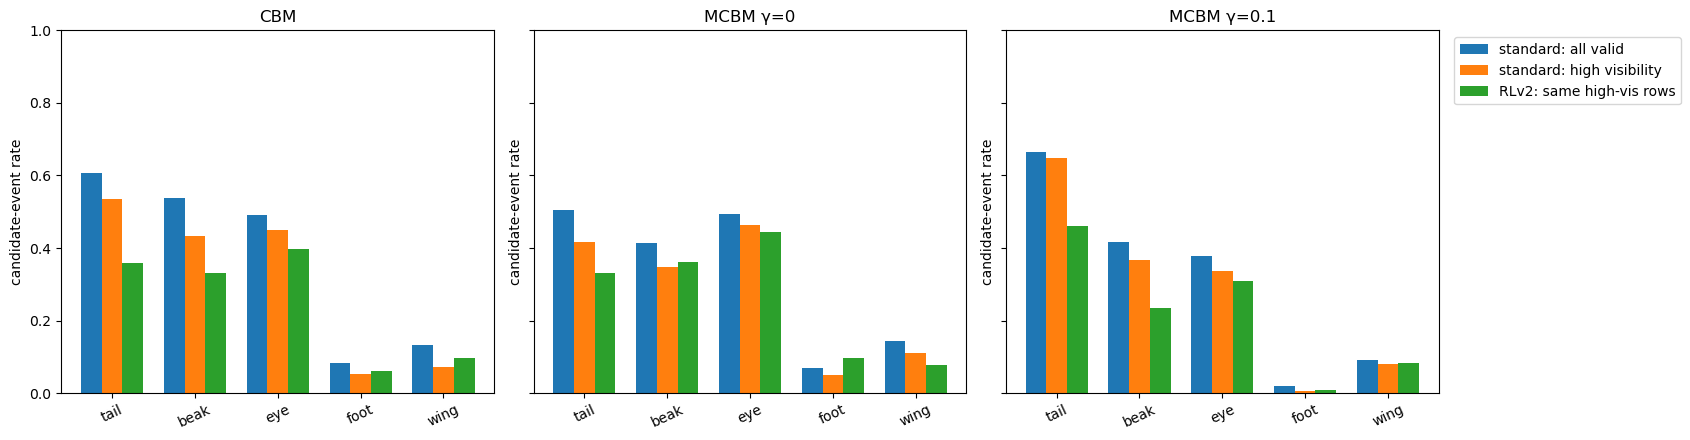

In [22]:
# Same-row waterfall. This never adds percentages from different populations.
proof_rows = []
remaining_rows = {}
for model, q0 in PAIRED.items():
    q = q0.copy()
    q["candidate_standard"] = (
        q["swap_moved_toward_donor_standard"].astype(bool)
        & q["margin_standard"].lt(0)
    )
    q["candidate_rl"] = (
        q["swap_moved_toward_donor_rl"].astype(bool)
        & q["margin_rl"].lt(0)
    )
    for part, d_all in q.groupby("part"):
        threshold = visibility_thresholds.get(part, 1)
        d = d_all.loc[d_all.pixel_count_cf_standard >= threshold].copy()
        if d.empty:
            continue
        resolved = d.candidate_standard & ~d.candidate_rl
        introduced = ~d.candidate_standard & d.candidate_rl
        remaining = d.candidate_standard & d.candidate_rl
        remaining_rows[(model, part)] = d.loc[remaining].copy()
        proof_rows.append({
            "model": model, "part": part,
            "n_all": len(d_all),
            "standard_rate_all": d_all.candidate_standard.mean(),
            "n_high_visibility": len(d),
            "standard_rate_high_visibility": d.candidate_standard.mean(),
            "rl_rate_same_high_visibility": d.candidate_rl.mean(),
            "resolved_1_to_0": resolved.mean(),
            "introduced_0_to_1": introduced.mean(),
            "remaining_1_to_1": remaining.mean(),
            "remaining_count": int(remaining.sum()),
        })

PROOF_WATERFALL = pd.DataFrame(proof_rows)
display(PROOF_WATERFALL.round(3))

fig, axes = plt.subplots(1, len(MODEL_FILES), figsize=(17, 4.5), sharey=True)
for ax, model in zip(axes, MODEL_FILES):
    d = PROOF_WATERFALL.query("model == @model").set_index("part").reindex(ORDER)
    x = np.arange(len(d)); w = .25
    ax.bar(x-w, d.standard_rate_all, w, label="standard: all valid")
    ax.bar(x, d.standard_rate_high_visibility, w, label="standard: high visibility")
    ax.bar(x+w, d.rl_rate_same_high_visibility, w, label="RLv2: same high-vis rows")
    ax.set_xticks(x); ax.set_xticklabels(ORDER, rotation=25)
    ax.set_title(model); ax.set_ylim(0, 1)
    ax.set_ylabel("candidate-event rate")
axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout(); plt.show()


,model,part,n,remaining_rate,baseline_brier,after_variant_direction_brier,after_source_species_brier,variant_direction_gain,additional_species_gain
0,CBM,beak,500,0.3300,0.2211,0.1509,0.1260,0.0702,0.0249
1,CBM,eye,494,0.3968,0.2393,0.2375,0.1859,0.0018,0.0516
2,CBM,foot,501,0.0619,0.0580,0.0539,0.0342,0.0041,0.0197
3,CBM,tail,409,0.3594,0.2302,0.1589,0.1569,0.0714,0.0020
4,CBM,wing,457,0.0963,0.0870,0.0808,0.0790,0.0062,0.0018
5,MCBM γ=0,beak,500,0.3620,0.2310,0.2018,0.1680,0.0292,0.0337
6,MCBM γ=0,eye,494,0.4433,0.2468,0.2413,0.1824,0.0055,0.0589
7,MCBM γ=0,foot,501,0.0978,0.0882,0.0809,0.0589,0.0073,0.0220
8,MCBM γ=0,tail,409,0.3325,0.2219,0.1787,0.1682,0.0433,0.0105
9,MCBM γ=0,wing,457,0.0788,0.0726,0.0635,0.0672,0.0090,-0.0036


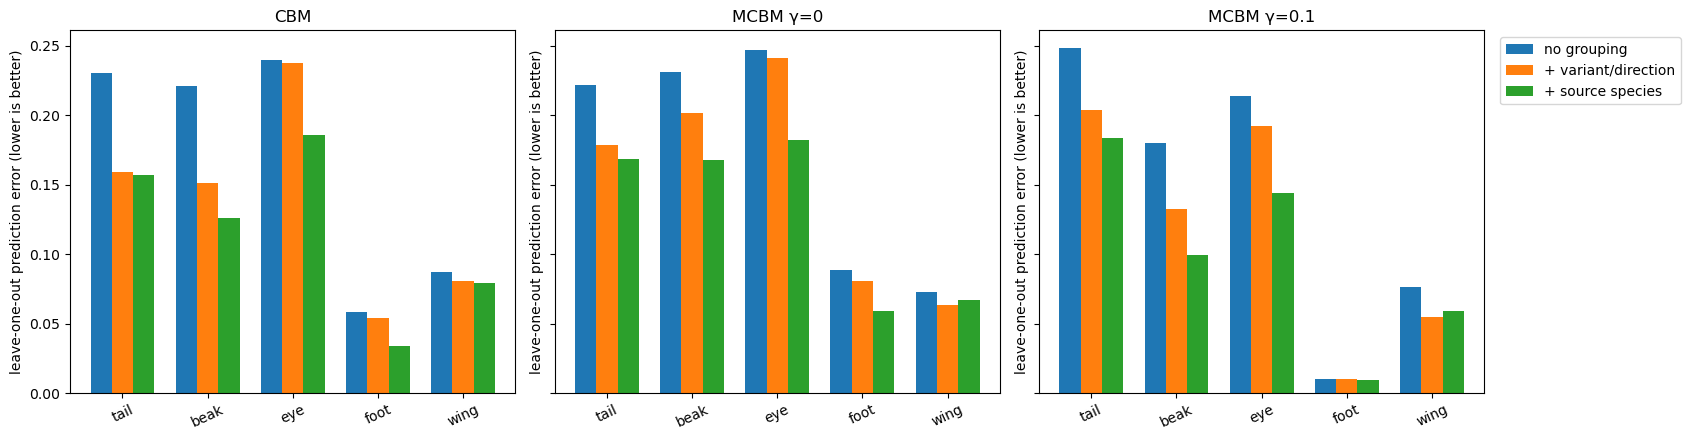

In [23]:
# Observational organization of the RLv2 remainder. Lower Brier error means the
# added grouping variables predict where candidate events remain more reliably.
def smoothed_loo_brier(d, outcome, group_cols, alpha=5.0):
    y = d[outcome].astype(float)
    p0 = float(y.mean())
    if not group_cols:
        return float(((y - p0) ** 2).mean())
    stats = d.assign(_y=y).groupby(group_cols, dropna=False)._y.agg(["sum", "count"])
    keyed = d[group_cols].merge(stats.reset_index(), on=group_cols, how="left")
    pred = (keyed["sum"].to_numpy() - y.to_numpy() + alpha * p0) / (
        keyed["count"].to_numpy() - 1 + alpha
    )
    return float(np.mean((y.to_numpy() - pred) ** 2))

organization_rows = []
for model, q0 in PAIRED.items():
    q = q0.copy()
    q["candidate_rl"] = (
        q.swap_moved_toward_donor_rl.astype(bool) & q.margin_rl.lt(0)
    )
    for part, d0 in q.groupby("part"):
        threshold = visibility_thresholds.get(part, 1)
        d = d0.loc[d0.pixel_count_cf_standard >= threshold].copy()
        if len(d) < 10:
            continue
        b0 = smoothed_loo_brier(d, "candidate_rl", [])
        bv = smoothed_loo_brier(
            d, "candidate_rl", ["var_src", "var_donor", "direction"]
        )
        bs = smoothed_loo_brier(
            d, "candidate_rl", ["var_src", "var_donor", "direction", "sid_src"]
        )
        organization_rows.append({
            "model": model, "part": part, "n": len(d),
            "remaining_rate": d.candidate_rl.mean(),
            "baseline_brier": b0,
            "after_variant_direction_brier": bv,
            "after_source_species_brier": bs,
            "variant_direction_gain": b0 - bv,
            "additional_species_gain": bv - bs,
        })

RESIDUAL_ORGANIZATION = pd.DataFrame(organization_rows)
display(RESIDUAL_ORGANIZATION.round(4))

fig, axes = plt.subplots(1, len(MODEL_FILES), figsize=(17, 4.5), sharey=True)
for ax, model in zip(axes, MODEL_FILES):
    d = RESIDUAL_ORGANIZATION.query("model == @model").set_index("part").reindex(ORDER)
    x = np.arange(len(d)); w = .25
    ax.bar(x-w, d.baseline_brier, w, label="no grouping")
    ax.bar(x, d.after_variant_direction_brier, w, label="+ variant/direction")
    ax.bar(x+w, d.after_source_species_brier, w, label="+ source species")
    ax.set_xticks(x); ax.set_xticklabels(ORDER, rotation=25)
    ax.set_title(model); ax.set_ylabel("leave-one-out prediction error (lower is better)")
axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout(); plt.show()


### How to read this figure

- First bar: all valid standard-training swaps.
- Second bar: only high-visibility swaps. Its change is **selection**, not a
  causal percentage removed by visibility.
- Third bar: the matched RLv2 model on those exact same images. The `1 -> 0`,
  `0 -> 1`, and `1 -> 1` columns are the causal label-intervention accounting.
- `1 -> 1` is what remains. Variant pair and source species may organize this
  remainder, but they do not become causes until separately manipulated.

The second figure asks whether exact variant/direction and then source species
help predict which same-image RLv2 candidate events remain. Falling prediction
error means that factor **organizes** the remainder. It is deliberately not
shown as “another percentage causally removed.” The final residual is the
remaining `1 -> 1` count plus whatever prediction error remains after the last
grouping step.

The final conclusion must report the remaining count. It must not imply that the
listed influences add to 100% or that all causes have been identified.
